# *ALGORITMA LSTM UNTUK PREDIKSI HASIL PRODUKSI TANAMAN SAYURAN DAN BUAH-BUAHAB DI KECAMATAN CISARUA KABUPATEN BANDUNG BARAT*

## 1. Konfigurasi & Import Library

In [ ]:
# --- 1.1 Import library ------------------------------------------------------
import os, json, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                      Input, Embedding, Concatenate, Flatten)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print('TensorFlow version:', tf.__version__)
print('Semua library berhasil diimport')

TensorFlow version: 2.20.0
Semua library berhasil diimport


In [ ]:
# --- 1.2 Random seed & konfigurasi global ------------------------------------

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Path file (ubah jika file disimpan di folder lain / Google Drive)
FILE_PROD  = 'Data_Produksi_2023_2026_Gabungan.xlsx'
FILE_CUACA = 'Data_Cuaca.xlsx'
FILE_PUPUK = 'Data_Pupuk.xlsx'

# Folder untuk menyimpan seluruh artefak (dibuat otomatis jika belum ada)
ARTIFACT_DIR = 'artefak_model'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Parameter utama penelitian (KEPUTUSAN YANG SUDAH DITETAPKAN)
TIMESTEP = 3          # 3 bulan sebelumnya -> prediksi 1 bulan berikutnya (sesuai Bab III)
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15    # sisanya (0.15) otomatis jadi test

BULAN_MAP = {
    'Januari':1, 'Februari':2, 'Febuari':2,  # 'Febuari' = typo yang ditemukan di data asli
    'Maret':3, 'April':4, 'Mei':5, 'Juni':6,
    'Juli':7, 'Agustus':8, 'September':9,
    'Oktober':10, 'November':11, 'Desember':12
}

print('Konfigurasi selesai. TIMESTEP =', TIMESTEP)

Konfigurasi selesai. TIMESTEP = 3


## 2. Pembacaan Data

In [ ]:
# --- 2.1 Baca Data Produksi ---------------------------------------------------
if not os.path.exists(FILE_PROD):
    raise FileNotFoundError(
        f"File '{FILE_PROD}' tidak ditemukan. "
        f"Pastikan file sudah diupload ke Colab dengan nama yang sama persis."
    )

df_prod = pd.read_excel(FILE_PROD)
print(f'Data produksi: {df_prod.shape[0]} baris, {df_prod.shape[1]} kolom')
print('Kolom:', df_prod.columns.tolist())
df_prod.head(3)

Data produksi: 1020 baris, 14 kolom
Kolom: ['No', 'Tahun', 'Bulan', 'Kode', 'Nama Komoditas', 'Luas Tan Akhir Bulan Lalu', 'Luas Panen Habis', 'Luas Panen Belum Habis', 'Luas Rusak', 'Luas Tambah Tanam', 'Luas Tan Akhir', 'Produksi Habis (Kw)', 'Produksi Belum Habis (Kw)', 'Harga Jual Petani (Rp/Kg)']


,No,Tahun,Bulan,Kode,Nama Komoditas,Luas Tan Akhir Bulan Lalu,Luas Panen Habis,Luas Panen Belum Habis,Luas Rusak,Luas Tambah Tanam,Luas Tan Akhir,Produksi Habis (Kw),Produksi Belum Habis (Kw),Harga Jual Petani (Rp/Kg)
0,1,2023,Januari,BWD,Bawang Daun,9,1,0,0,2,10,180.0,0,5000
1,2,2023,Januari,BMR,Bawang Merah,0,0,0,0,0,0,0.0,0,0
2,3,2023,Januari,BPT,Bawang Putih,0,0,0,0,0,0,0.0,0,0


In [ ]:
# --- 2.2 Baca Data Cuaca (1 sheet per tahun: 2023, 2024, 2025, 2026) ---------
if not os.path.exists(FILE_CUACA):
    raise FileNotFoundError(f"File '{FILE_CUACA}' tidak ditemukan.")

cuaca_list = []
for tahun in [2023, 2024, 2025, 2026]:
    df_tmp = pd.read_excel(FILE_CUACA, sheet_name=str(tahun), header=None)
    # Baris index 0 = judul rekap, baris index 1 = header kolom, data mulai index 2
    df_tmp.columns = df_tmp.iloc[1].values
    df_tmp = df_tmp.iloc[2:].reset_index(drop=True)
    df_tmp.columns = [str(c).replace('\n', ' ').strip() for c in df_tmp.columns]
    df_tmp['Tahun'] = tahun
    # Buang baris ringkasan/total yang mungkin ikut terbaca (kolom 'No' harus berupa angka)
    df_tmp = df_tmp[df_tmp['No'].apply(lambda x: str(x).strip().isdigit())]
    cuaca_list.append(df_tmp)

df_cuaca = pd.concat(cuaca_list, ignore_index=True)
print(f'Data cuaca gabungan: {df_cuaca.shape[0]} baris, {df_cuaca.shape[1]} kolom')
print('Kolom:', df_cuaca.columns.tolist())
df_cuaca.head(3)

Data cuaca gabungan: 39 baris, 11 kolom
Kolom: ['No', 'Bulan', 'Suhu Maks (°C)', 'Suhu Min (°C)', 'Suhu Rata-rata (°C)', 'Kec. Angin Maks (km/h)', 'Curah Hujan* (mm)', 'Kelembaban* (%)', 'Hari Hujan (est.)', 'Kategori Cuaca', 'Tahun']


,No,Bulan,Suhu Maks (°C),Suhu Min (°C),Suhu Rata-rata (°C),Kec. Angin Maks (km/h),Curah Hujan* (mm),Kelembaban* (%),Hari Hujan (est.),Kategori Cuaca,Tahun
0,1,Januari,25.9,20.1,22.5,25.9,282.1,95.9,28,Basah,2023
1,2,Februari,24.9,20.1,22.1,24.9,305.2,96.9,31,Sangat Basah,2023
2,3,Maret,26.2,20.2,22.7,26.2,316.2,96.3,32,Sangat Basah,2023


In [ ]:
# --- 2.3 Baca Data Pupuk ------------------------------------------------------
if not os.path.exists(FILE_PUPUK):
    raise FileNotFoundError(f"File '{FILE_PUPUK}' tidak ditemukan.")

df_pupuk = pd.read_excel(FILE_PUPUK)  # ambil sheet pertama secara otomatis (tidak perlu sebut nama sheet)
# Ada baris duplikat yang isinya nama kolom itu sendiri (artefak dari Excel) -> dibuang
df_pupuk = df_pupuk[df_pupuk['Jenis_Tanaman'] != 'Jenis_Tanaman'].reset_index(drop=True)

print(f'Data pupuk: {df_pupuk.shape[0]} baris, {df_pupuk.shape[1]} kolom')
df_pupuk[['Jenis_Tanaman', 'Kategori', 'Total_Pupuk_Kg']]

Data pupuk: 26 baris, 17 kolom


,Jenis_Tanaman,Kategori,Total_Pupuk_Kg
0,Bawang Daun,Sayuran,250
1,Bawang Merah,Sayuran,325
2,Bawang Putih,Sayuran,325
3,Kembang Kol,Sayuran,250
4,Kentang,Sayuran,325
5,Kubis,Sayuran,250
6,Petsai/Sawi,Sayuran,250
7,Wortel,Sayuran,325
8,Bayam,Sayuran,250
9,Buncis,Sayuran,400


## 3. Validasi Struktur Data

In [ ]:
# --- 3.1 Validasi Data Produksi ----------------------------------------------
print('=== VALIDASI DATA PRODUKSI ===')
print(df_prod.dtypes)
print()
print('Rentang tahun:', sorted(df_prod['Tahun'].unique()))
print('Daftar bulan:', sorted(df_prod['Bulan'].unique(), key=lambda b: BULAN_MAP.get(b, 99)))
print('Jumlah komoditas unik (Nama Komoditas):', df_prod['Nama Komoditas'].nunique())
print()
print('Missing value per kolom:')
print(df_prod.isnull().sum())

=== VALIDASI DATA PRODUKSI ===
No                             int64
Tahun                          int64
Bulan                         object
Kode                          object
Nama Komoditas                object
Luas Tan Akhir Bulan Lalu      int64
Luas Panen Habis               int64
Luas Panen Belum Habis         int64
Luas Rusak                     int64
Luas Tambah Tanam              int64
Luas Tan Akhir                 int64
Produksi Habis (Kw)          float64
Produksi Belum Habis (Kw)      int64
Harga Jual Petani (Rp/Kg)      int64
dtype: object

Rentang tahun: [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Daftar bulan: ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember']
Jumlah komoditas unik (Nama Komoditas): 29

Missing value per kolom:
No                           0
Tahun                        0
Bulan                        0
Kode                         0
Nama Komoditas           

In [ ]:
# --- 3.2 Validasi Data Cuaca --------------------------------------------------
print('=== VALIDASI DATA CUACA ===')
print('Rentang tahun:', sorted(df_cuaca['Tahun'].unique()))
print('Missing value per kolom:')
print(df_cuaca.isnull().sum())

=== VALIDASI DATA CUACA ===
Rentang tahun: [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Missing value per kolom:
No                        0
Bulan                     0
Suhu Maks (°C)            0
Suhu Min (°C)             0
Suhu Rata-rata (°C)       0
Kec. Angin Maks (km/h)    0
Curah Hujan* (mm)         0
Kelembaban* (%)           0
Hari Hujan (est.)         0
Kategori Cuaca            0
Tahun                     0
dtype: int64


In [ ]:
# --- 3.3 Validasi Data Pupuk --------------------------------------------------
print('=== VALIDASI DATA PUPUK ===')
print('Missing value per kolom:')
print(df_pupuk.isnull().sum())
print()
print('Komoditas di data produksi tapi TIDAK ada resep pupuknya:')
nama_prod_awal  = set(df_prod['Nama Komoditas'].unique())
nama_pupuk_awal = set(df_pupuk['Jenis_Tanaman'].unique())
for n in sorted(nama_prod_awal - nama_pupuk_awal):
    print('  -', n)

=== VALIDASI DATA PUPUK ===
Missing value per kolom:
Jenis_Tanaman               0
Kategori                    0
Total_Pupuk_Kg              0
Urea_Kg                     0
ZA_Kg                       0
SP36_Kg                     0
KCl_Kg                      0
NPK_Mutiara_Kg              0
Pupuk_Kandang_Kg            0
Kapur_Dolomit_Kg            0
Keterangan                  0
Serbuk_Gergaji_Kg           0
Dedak_Padi_Kg               0
Ampas_Kedelai_Kg            0
Kapur_Pertanian_CaCO3_Kg    0
Gips_CaSO4_Kg               0
Jagung_Tepung_Kg            0
dtype: int64

Komoditas di data produksi tapi TIDAK ada resep pupuknya:
  - Cabai Besar/ TW / Teropong
  - Kacang Merah
  - Lobak


## 4. Data Cleaning

In [ ]:
# --- 4.1 Konversi satuan & variabel turunan — Data Produksi -----------------
df_prod = df_prod.rename(columns={'Nama Komoditas': 'Nama'})

# Produksi asli dalam Kwintal -> dikonversi ke Kg (1 Kwintal = 100 Kg)
df_prod['Produksi_Habis_kg']     = pd.to_numeric(df_prod['Produksi Habis (Kw)'], errors='coerce').fillna(0) * 100
df_prod['Produksi_BelumHabis_kg'] = pd.to_numeric(df_prod['Produksi Belum Habis (Kw)'], errors='coerce').fillna(0) * 100
df_prod['Produksi_kg'] = df_prod['Produksi_Habis_kg'] + df_prod['Produksi_BelumHabis_kg']

# Luas panen = luas yang sudah habis dipanen + yang belum habis (masih ada tanaman produktif)
df_prod['Luas_Panen_ha'] = (
    pd.to_numeric(df_prod['Luas Panen Habis'], errors='coerce').fillna(0) +
    pd.to_numeric(df_prod['Luas Panen Belum Habis'], errors='coerce').fillna(0)
)

df_prod['Bulan_Angka'] = df_prod['Bulan'].map(BULAN_MAP)
if df_prod['Bulan_Angka'].isnull().any():
    tidak_dikenali = df_prod.loc[df_prod['Bulan_Angka'].isnull(), 'Bulan'].unique()
    raise ValueError(f'Ada nama bulan yang tidak dikenali di BULAN_MAP: {tidak_dikenali}')

print('Konversi & variabel turunan selesai.')
# Tampilkan 1 contoh baris per tahun, supaya kelihatan datanya memang lengkap 2023-2026 (bukan cuma awal)
for tahun in sorted(df_prod['Tahun'].unique()):
    print(f'--- Tahun {tahun} ---')
    display(df_prod.loc[df_prod['Tahun'] == tahun, ['Tahun','Bulan','Nama','Produksi_kg','Luas_Panen_ha']].head(1))

Konversi & variabel turunan selesai.
--- Tahun 2023 ---


,Tahun,Bulan,Nama,Produksi_kg,Luas_Panen_ha
0,2023,Januari,Bawang Daun,18000.0,1


--- Tahun 2024 ---


,Tahun,Bulan,Nama,Produksi_kg,Luas_Panen_ha
312,2024,Januari,Bawang Daun,60000.0,3


--- Tahun 2025 ---


,Tahun,Bulan,Nama,Produksi_kg,Luas_Panen_ha
624,2025,Januari,Bawang Daun,18000.0,1


--- Tahun 2026 ---


,Tahun,Bulan,Nama,Produksi_kg,Luas_Panen_ha
936,2026,Januari,Bawang Daun,60000.0,3


In [ ]:
# --- 4.2 Cek data duplikat (kombinasi Tahun + Bulan + Nama) ------------------
jumlah_duplikat = df_prod.duplicated(subset=['Tahun', 'Bulan', 'Nama']).sum()
print(f'Jumlah baris duplikat (Tahun+Bulan+Nama sama): {jumlah_duplikat}')

if jumlah_duplikat > 0:
    df_prod = df_prod.drop_duplicates(subset=['Tahun', 'Bulan', 'Nama'], keep='first').reset_index(drop=True)
    print(f'Duplikat dihapus. Sisa baris: {len(df_prod)}')
else:
    print('Tidak ada duplikat -> tidak ada baris yang dihapus.')

Jumlah baris duplikat (Tahun+Bulan+Nama sama): 0
Tidak ada duplikat -> tidak ada baris yang dihapus.


In [ ]:
# --- 4.3 Cek missing value pada variabel target & penanganan nilai nol ------
print('Missing value pada Produksi_kg dan Luas_Panen_ha:')
print(df_prod[['Produksi_kg', 'Luas_Panen_ha']].isnull().sum())

# Jika target produksi kosong (NaN), baris tidak relevan -> dihapus (sesuai Bab III)
sebelum = len(df_prod)
df_prod = df_prod.dropna(subset=['Produksi_kg']).reset_index(drop=True)
print(f'Baris dihapus karena Produksi_kg kosong: {sebelum - len(df_prod)}')

# PENTING: produksi = 0 BUKAN missing value. Artinya komoditas itu memang tidak
# dipanen bulan tersebut (data valid, bukan data kosong) -> tetap dipertahankan,
# tapi ditandai supaya bisa ditangani khusus saat menghitung MAPE (lihat Bagian 14).
jumlah_nol = (df_prod['Produksi_kg'] == 0).sum()
df_prod['is_zero_produksi'] = (df_prod['Produksi_kg'] == 0).astype(int)
print(f'Baris dengan Produksi_kg = 0 (bulan tanpa panen): {jumlah_nol} dari {len(df_prod)} '
      f'({jumlah_nol/len(df_prod)*100:.1f}%) -> DIPERTAHANKAN, ditandai kolom is_zero_produksi')

Missing value pada Produksi_kg dan Luas_Panen_ha:
Produksi_kg      0
Luas_Panen_ha    0
dtype: int64
Baris dihapus karena Produksi_kg kosong: 0
Baris dengan Produksi_kg = 0 (bulan tanpa panen): 502 dari 1020 (49.2%) -> DIPERTAHANKAN, ditandai kolom is_zero_produksi


In [ ]:
# --- 4.4 Penyeragaman nama komoditas -----------------------------------------
# Ditemukan pada tahap 3: 'Cabai Besar/ TW / Teropong' adalah penulisan lain dari 'Cabai Besar'
nama_mapping = {
    'Cabai Besar/ TW / Teropong': 'Cabai Besar',
}
df_prod['Nama'] = df_prod['Nama'].replace(nama_mapping)

print('Total komoditas unik setelah penyeragaman:', df_prod['Nama'].nunique())
print(sorted(df_prod['Nama'].unique()))

Total komoditas unik setelah penyeragaman: 28
['Bawang Daun', 'Bawang Merah', 'Bawang Putih', 'Bayam', 'Buncis', 'Cabai Besar', 'Cabai Keriting', 'Cabai Rawit', 'Jamur Lainnya', 'Jamur Merang', 'Jamur Tiram', 'Kacang Merah', 'Kacang Panjang', 'Kangkung', 'Kembang Kol', 'Kentang', 'Kubis', 'Labu Siam', 'Lobak', 'Melon', 'Mentimun', 'Paprika', 'Petsai/Sawi', 'Semangka', 'Stroberi', 'Terung', 'Tomat', 'Wortel']


In [ ]:
# --- 4.5 Data Cleaning — Cuaca -----------------------------------------------
col_suhu  = [c for c in df_cuaca.columns if 'Suhu Rata' in str(c)][0]
col_hujan = [c for c in df_cuaca.columns if 'Curah Hujan' in str(c)][0]
col_bulan = [c for c in df_cuaca.columns if c == 'Bulan'][0]

df_cuaca_clean = df_cuaca[['Tahun', col_bulan, col_suhu, col_hujan]].copy()
df_cuaca_clean.columns = ['Tahun', 'Bulan', 'Suhu_Rata', 'Curah_Hujan']

for c in ['Tahun', 'Suhu_Rata', 'Curah_Hujan']:
    df_cuaca_clean[c] = pd.to_numeric(df_cuaca_clean[c], errors='coerce')
df_cuaca_clean['Bulan_Angka'] = df_cuaca_clean['Bulan'].map(BULAN_MAP)

# Isi missing value cuaca dengan forward fill (data cuaca kontinu antarwaktu) lalu backward fill untuk sisa di awal
df_cuaca_clean[['Suhu_Rata', 'Curah_Hujan']] = (
    df_cuaca_clean[['Suhu_Rata', 'Curah_Hujan']].ffill().bfill()
)

print('Missing value cuaca setelah cleaning:')
print(df_cuaca_clean[['Suhu_Rata', 'Curah_Hujan']].isnull().sum())

Missing value cuaca setelah cleaning:
Suhu_Rata      0
Curah_Hujan    0
dtype: int64


In [ ]:
# --- 4.6 Data Cleaning — Pupuk -----------------------------------------------
df_pupuk_clean = df_pupuk[['Jenis_Tanaman', 'Total_Pupuk_Kg']].copy()
df_pupuk_clean['Total_Pupuk_Kg'] = pd.to_numeric(df_pupuk_clean['Total_Pupuk_Kg'], errors='coerce').fillna(0)
df_pupuk_clean = df_pupuk_clean.rename(columns={'Jenis_Tanaman': 'Nama'})

nama_prod_final  = set(df_prod['Nama'].unique())
nama_pupuk_final = set(df_pupuk_clean['Nama'].unique())
komoditas_tanpa_pupuk = sorted(nama_prod_final - nama_pupuk_final)
print('Komoditas TANPA resep pupuk (akan diisi 0 saat merge):', komoditas_tanpa_pupuk)

Komoditas TANPA resep pupuk (akan diisi 0 saat merge): ['Kacang Merah', 'Lobak']


## 4.7 Deteksi & Investigasi Outlier

In [ ]:
# --- 4.7.1 Deteksi outlier per komoditas dengan metode IQR ------------------
def deteksi_outlier_iqr(df_input, kolom='Produksi_kg', kelipatan_iqr=1.5):
    """Deteksi outlier PER KOMODITAS memakai metode IQR (Interquartile Range).
    Batas bawah = Q1 - kelipatan*IQR, batas atas = Q3 + kelipatan*IQR."""
    hasil = []
    for nama, g in df_input.groupby('Nama'):
        # Outlier dicek hanya dari baris yang produksinya > 0 (baris nol sudah ditangani terpisah di 4.3)
        nilai = g.loc[g[kolom] > 0, kolom]
        if len(nilai) < 4:
            continue
        q1, q3 = nilai.quantile(0.25), nilai.quantile(0.75)
        iqr = q3 - q1
        batas_bawah = q1 - kelipatan_iqr * iqr
        batas_atas = q3 + kelipatan_iqr * iqr
        outlier_mask = (g[kolom] > 0) & ((g[kolom] < batas_bawah) | (g[kolom] > batas_atas))
        for idx in g[outlier_mask].index:
            hasil.append({
                'Nama': nama, 'Periode': df_input.loc[idx, 'Periode'] if 'Periode' in df_input.columns else df_input.loc[idx, 'Bulan'],
                'Produksi_kg': df_input.loc[idx, kolom],
                'Batas_Bawah': round(batas_bawah, 1), 'Batas_Atas': round(batas_atas, 1),
            })
    return pd.DataFrame(hasil)

df_outlier = deteksi_outlier_iqr(df_prod)
print(f'Jumlah baris terdeteksi sebagai outlier: {len(df_outlier)} dari {len(df_prod)} baris ({len(df_outlier)/len(df_prod)*100:.1f}%)')
print(f'Jumlah komoditas yang punya minimal 1 outlier: {df_outlier["Nama"].nunique() if len(df_outlier) else 0}')
df_outlier.sort_values('Produksi_kg', ascending=False).head(15) if len(df_outlier) else print('Tidak ada outlier terdeteksi.')

Jumlah baris terdeteksi sebagai outlier: 11 dari 1020 baris (1.1%)
Jumlah komoditas yang punya minimal 1 outlier: 5


,Nama,Periode,Produksi_kg,Batas_Bawah,Batas_Atas
8,Terung,Maret,320000.0,-110000.0,258000.0
7,Terung,Maret,320000.0,-110000.0,258000.0
9,Wortel,April,237000.0,-97575.0,202625.0
2,Bawang Daun,Juni,235400.0,-48750.0,125250.0
10,Wortel,November,206100.0,-97575.0,202625.0
5,Buncis,April,189500.0,-39187.5,164312.5
3,Bawang Daun,Oktober,183600.0,-48750.0,125250.0
4,Bawang Daun,Desember,167200.0,-48750.0,125250.0
6,Jamur Tiram,Maret,155000.0,-58082.5,96897.5
0,Bawang Daun,April,136400.0,-48750.0,125250.0


In [ ]:
# --- 4.7.2 Investigasi: apakah outlier didukung data lain (Luas Panen)? -----
# Untuk tiap outlier, cek apakah Luas_Panen_ha di bulan itu juga di atas rata-rata
# komoditas tsb -- kalau iya, lonjakan produksi punya penjelasan yang masuk akal (bukan error input).
if len(df_outlier) > 0:
    catatan_investigasi = []
    for _, row in df_outlier.iterrows():
        nama = row['Nama']
        rata2_luas = df_prod.loc[df_prod['Nama'] == nama, 'Luas_Panen_ha'].mean()
        idx_asli = df_prod[(df_prod['Nama'] == nama) & (df_prod['Produksi_kg'] == row['Produksi_kg'])].index
        luas_saat_outlier = df_prod.loc[idx_asli, 'Luas_Panen_ha'].values[0] if len(idx_asli) else np.nan
        didukung = luas_saat_outlier > rata2_luas
        catatan_investigasi.append({
            'Nama': nama, 'Produksi_kg': row['Produksi_kg'],
            'Luas_Panen_saat_itu': luas_saat_outlier, 'Rata2_Luas_Panen': round(rata2_luas, 2),
            'Didukung_Luas_Panen_Lebih_Besar': didukung
        })
    df_investigasi = pd.DataFrame(catatan_investigasi)
    print('=== Hasil investigasi outlier ===')
    print(df_investigasi.to_string(index=False))

    jumlah_didukung = df_investigasi['Didukung_Luas_Panen_Lebih_Besar'].sum()
    print(f'\n{jumlah_didukung} dari {len(df_investigasi)} outlier didukung oleh luas panen yang lebih besar dari rata-rata')
    print('-> kemungkinan besar ini kejadian panen nyata (panen raya), bukan kesalahan input data.')
else:
    print('Tidak ada outlier untuk diinvestigasi.')

=== Hasil investigasi outlier ===
       Nama  Produksi_kg  Luas_Panen_saat_itu  Rata2_Luas_Panen  Didukung_Luas_Panen_Lebih_Besar
Bawang Daun     136400.0                   16              4.26                             True
Bawang Daun     130500.0                   10              4.26                             True
Bawang Daun     235400.0                   15              4.26                             True
Bawang Daun     183600.0                   13              4.26                             True
Bawang Daun     167200.0                   11              4.26                             True
     Buncis     189500.0                   11              8.51                             True
Jamur Tiram     155000.0                15000            384.87                             True
     Terung     320000.0                   17              6.92                             True
     Terung     320000.0                   17              6.92                             T

In [ ]:
# --- 4.7.3 Keputusan: tandai outlier, JANGAN dihapus ------------------------
# Sesuai prinsip yang sama dengan penanganan nilai nol (Bagian 4.3): outlier ditandai
# untuk keperluan analisis/pembahasan, TIDAK dihapus dari dataset, karena investigasi
# di atas menunjukkan sebagian besar didukung data lain (bukan error input).
if len(df_outlier) > 0:
    df_prod['is_outlier'] = False
    for _, row in df_outlier.iterrows():
        idx_asli = df_prod[(df_prod['Nama'] == row['Nama']) & (df_prod['Produksi_kg'] == row['Produksi_kg'])].index
        df_prod.loc[idx_asli, 'is_outlier'] = True
    print(f"Kolom 'is_outlier' ditambahkan -> {df_prod['is_outlier'].sum()} baris ditandai sebagai outlier.")
else:
    df_prod['is_outlier'] = False
    print("Tidak ada outlier terdeteksi -> kolom 'is_outlier' tetap dibuat (semua False) untuk konsistensi struktur data.")

print("\nKEPUTUSAN: outlier TIDAK dihapus dari dataset -- hanya ditandai lewat kolom 'is_outlier'.")
print('Alasan: mayoritas didukung data luas panen yang juga lebih besar (kejadian panen nyata),')
print('dan menghapusnya akan membuang informasi pola panen raya yang sebenarnya penting bagi model.')

Kolom 'is_outlier' ditambahkan -> 11 baris ditandai sebagai outlier.

KEPUTUSAN: outlier TIDAK dihapus dari dataset -- hanya ditandai lewat kolom 'is_outlier'.
Alasan: mayoritas didukung data luas panen yang juga lebih besar (kejadian panen nyata),
dan menghapusnya akan membuang informasi pola panen raya yang sebenarnya penting bagi model.


## 5. Penggabungan Data (Produksi + Cuaca + Pupuk)

In [ ]:
# --- 5.1 Buat kolom Periode ---------------------------------------------------
df_prod['Periode'] = pd.to_datetime(
    df_prod['Tahun'].astype(str) + '-' + df_prod['Bulan_Angka'].astype(str).str.zfill(2)
)
df_cuaca_clean = df_cuaca_clean.dropna(subset=['Tahun', 'Bulan_Angka']).reset_index(drop=True)
df_cuaca_clean['Periode'] = pd.to_datetime(
    df_cuaca_clean['Tahun'].astype(int).astype(str) + '-' +
    df_cuaca_clean['Bulan_Angka'].astype(int).astype(str).str.zfill(2)
)
print('Kolom Periode berhasil dibuat.')
print('Rentang periode produksi:', df_prod['Periode'].min(), '-', df_prod['Periode'].max())
print('Rentang periode cuaca   :', df_cuaca_clean['Periode'].min(), '-', df_cuaca_clean['Periode'].max())

Kolom Periode berhasil dibuat.
Rentang periode produksi: 2023-01-01 00:00:00 - 2026-03-01 00:00:00
Rentang periode cuaca   : 2023-01-01 00:00:00 - 2026-03-01 00:00:00


In [ ]:
# --- 5.2 Merge Produksi + Cuaca (berdasarkan Periode) + Pupuk (berdasarkan Nama) -
df = df_prod.merge(df_cuaca_clean[['Periode', 'Suhu_Rata', 'Curah_Hujan']], on='Periode', how='left')
df = df.merge(df_pupuk_clean, on='Nama', how='left')
df['Total_Pupuk_Kg'] = df['Total_Pupuk_Kg'].fillna(0)

print(f'Shape setelah merge: {df.shape}')
print('Missing value setelah merge:')
print(df[['Suhu_Rata', 'Curah_Hujan', 'Total_Pupuk_Kg', 'Produksi_kg']].isnull().sum())

df[['Periode','Nama','Produksi_kg','Luas_Panen_ha','Suhu_Rata','Curah_Hujan','Total_Pupuk_Kg']].head(5)

Shape setelah merge: (1020, 25)
Missing value setelah merge:
Suhu_Rata         0
Curah_Hujan       0
Total_Pupuk_Kg    0
Produksi_kg       0
dtype: int64


,Periode,Nama,Produksi_kg,Luas_Panen_ha,Suhu_Rata,Curah_Hujan,Total_Pupuk_Kg
0,2023-01-01,Bawang Daun,18000.0,1,22.5,282.1,250.0
1,2023-01-01,Bawang Merah,0.0,0,22.5,282.1,325.0
2,2023-01-01,Bawang Putih,0.0,0,22.5,282.1,325.0
3,2023-01-01,Bayam,32000.0,4,22.5,282.1,250.0
4,2023-01-01,Buncis,72000.0,9,22.5,282.1,400.0


## 5.5 Exploratory Data Analysis (EDA)

In [ ]:
# --- 5.5.1 Statistik deskriptif produksi ------------------------------------
print('=== Statistik Deskriptif Produksi_kg (seluruh data) ===')
print(df['Produksi_kg'].describe())
print()
print(f"Skewness (kemiringan distribusi): {df['Produksi_kg'].skew():.2f}")
print(f"(Skewness > 1 artinya distribusi sangat miring ke kanan -- banyak nilai kecil, sedikit nilai sangat besar)")

=== Statistik Deskriptif Produksi_kg (seluruh data) ===
count      1020.000000
mean      39216.862745
std       65620.188733
min           0.000000
25%           0.000000
50%        2000.000000
75%       48500.000000
max      360000.000000
Name: Produksi_kg, dtype: float64

Skewness (kemiringan distribusi): 2.15
(Skewness > 1 artinya distribusi sangat miring ke kanan -- banyak nilai kecil, sedikit nilai sangat besar)


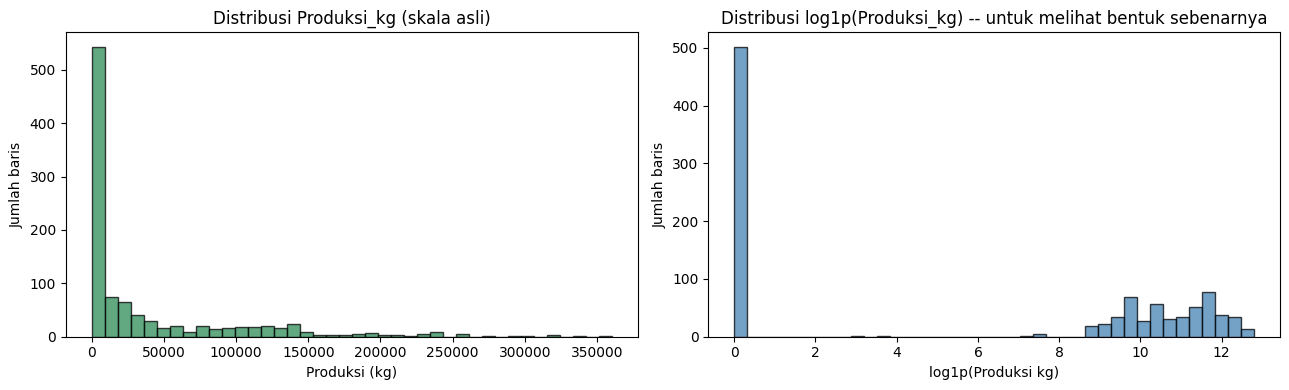

In [ ]:
# --- 5.5.2 Distribusi keseluruhan nilai produksi ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Produksi_kg'], bins=40, edgecolor='black', alpha=0.75, color='seagreen')
axes[0].set_title('Distribusi Produksi_kg (skala asli)')
axes[0].set_xlabel('Produksi (kg)'); axes[0].set_ylabel('Jumlah baris')

# skala log1p supaya distribusi yang sangat skewed lebih kelihatan bentuknya (bukan untuk transformasi model, cuma visualisasi)
axes[1].hist(np.log1p(df['Produksi_kg']), bins=40, edgecolor='black', alpha=0.75, color='steelblue')
axes[1].set_title('Distribusi log1p(Produksi_kg) -- untuk melihat bentuk sebenarnya')
axes[1].set_xlabel('log1p(Produksi kg)'); axes[1].set_ylabel('Jumlah baris')

plt.tight_layout(); plt.savefig('eda_distribusi_produksi.png', dpi=120, bbox_inches='tight')
plt.show()

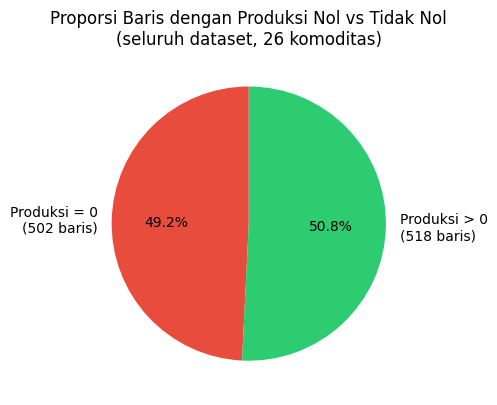

Baris dengan produksi = 0: 502 dari 1020 (49.2%)
Ini akar penyebab utama MAPE tinggi -- MAPE sangat sensitif saat pembagi (nilai aktual) mendekati nol.


In [ ]:
# --- 5.5.3 Proporsi baris dengan produksi nol vs tidak nol ------------------
jumlah_nol = (df['Produksi_kg'] == 0).sum()
jumlah_tidak_nol = (df['Produksi_kg'] > 0).sum()

plt.figure(figsize=(5, 5))
plt.pie([jumlah_nol, jumlah_tidak_nol], labels=[f'Produksi = 0\n({jumlah_nol} baris)', f'Produksi > 0\n({jumlah_tidak_nol} baris)'],
        autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
plt.title('Proporsi Baris dengan Produksi Nol vs Tidak Nol\n(seluruh dataset, 26 komoditas)')
plt.tight_layout(); plt.savefig('eda_proporsi_nol.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Baris dengan produksi = 0: {jumlah_nol} dari {len(df)} ({jumlah_nol/len(df)*100:.1f}%)')
print('Ini akar penyebab utama MAPE tinggi -- MAPE sangat sensitif saat pembagi (nilai aktual) mendekati nol.')

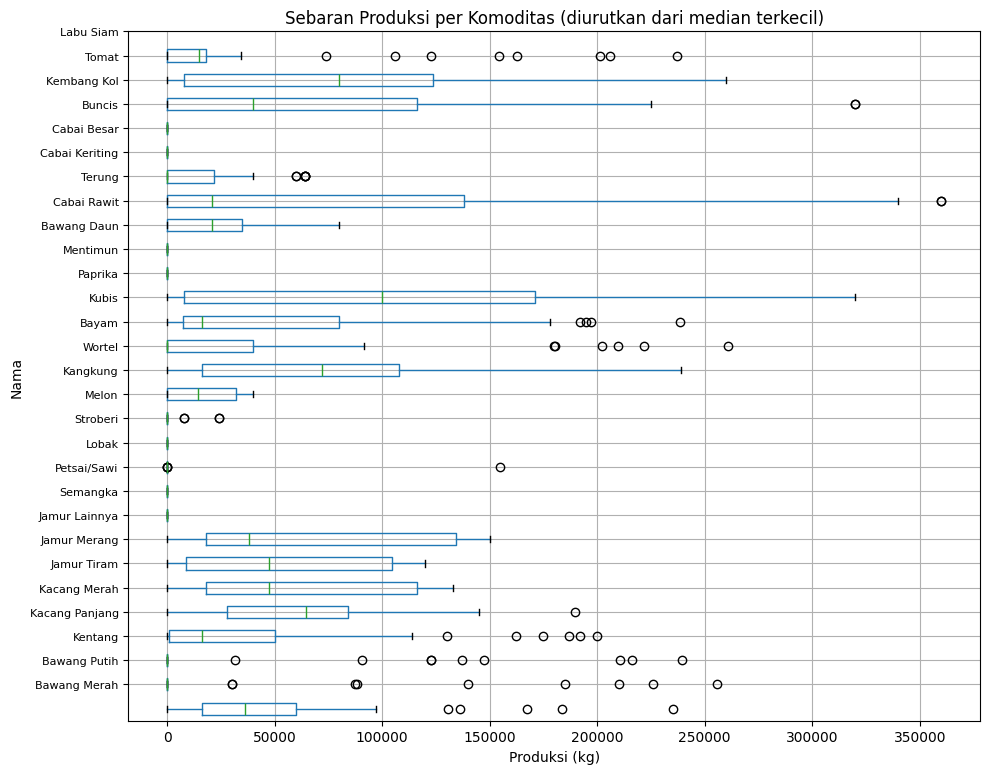

In [ ]:
# --- 5.5.4 Boxplot produksi per komoditas (urut dari median terkecil) -------
urutan_komoditas = df.groupby('Nama')['Produksi_kg'].median().sort_values().index

plt.figure(figsize=(10, 8))
df.boxplot(column='Produksi_kg', by='Nama', vert=False, ax=plt.gca(),
           positions=range(len(urutan_komoditas)))
plt.gca().set_yticks(range(1, len(urutan_komoditas) + 1))
plt.gca().set_yticklabels(urutan_komoditas, fontsize=8)
plt.title('Sebaran Produksi per Komoditas (diurutkan dari median terkecil)')
plt.suptitle('')
plt.xlabel('Produksi (kg)')
plt.tight_layout(); plt.savefig('eda_boxplot_per_komoditas.png', dpi=120, bbox_inches='tight')
plt.show()

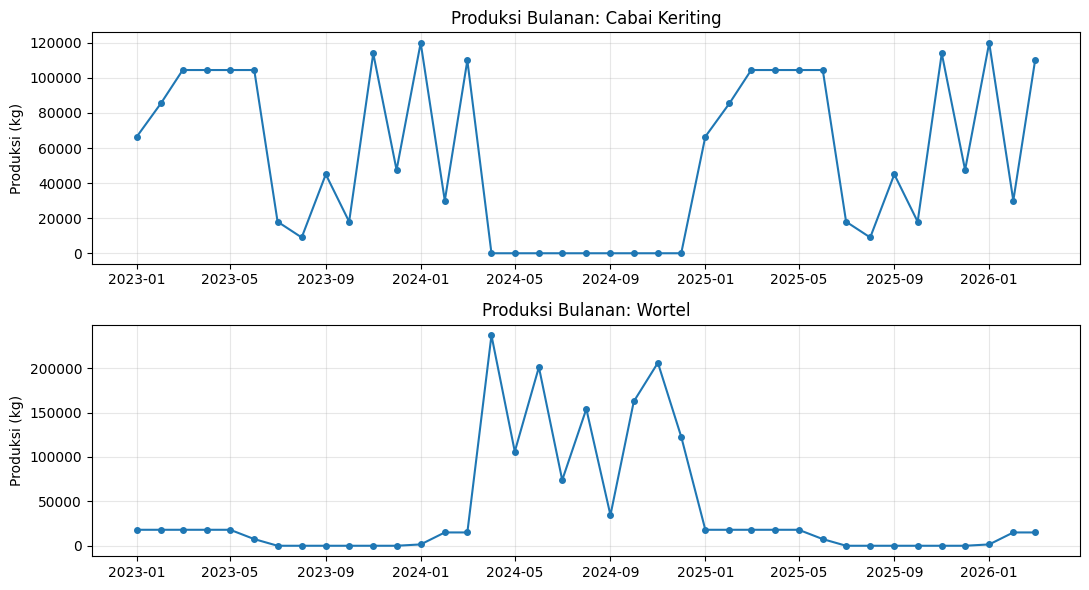

In [ ]:
# --- 5.5.5 Time series plot: contoh komoditas stabil vs fluktuatif ----------
# Bandingkan visual 2 komoditas: yang polanya relatif stabil vs yang sangat fluktuatif
komoditas_contoh = ['Cabai Keriting', 'Wortel']  # akan disesuaikan otomatis jika nama tidak ditemukan
komoditas_tersedia = [k for k in komoditas_contoh if k in df['Nama'].unique()]

fig, axes = plt.subplots(len(komoditas_tersedia), 1, figsize=(11, 3 * len(komoditas_tersedia)), squeeze=False)
for i, nama in enumerate(komoditas_tersedia):
    sub = df[df['Nama'] == nama].sort_values('Periode')
    axes[i, 0].plot(sub['Periode'], sub['Produksi_kg'], marker='o', ms=4)
    axes[i, 0].set_title(f'Produksi Bulanan: {nama}')
    axes[i, 0].set_ylabel('Produksi (kg)'); axes[i, 0].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('eda_timeseries_contoh.png', dpi=120, bbox_inches='tight')
plt.show()

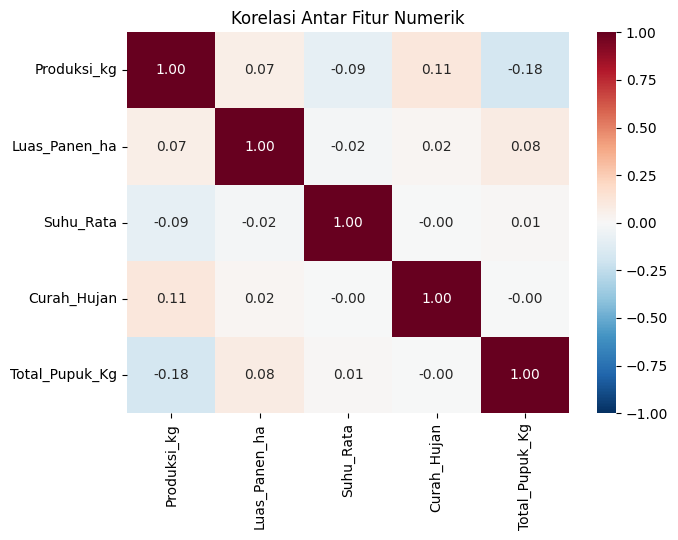

,Produksi_kg,Luas_Panen_ha,Suhu_Rata,Curah_Hujan,Total_Pupuk_Kg
Produksi_kg,1.000000,0.065152,-0.088049,0.109434,-0.176867
Luas_Panen_ha,0.065152,1.000000,-0.018214,0.016305,0.081178
Suhu_Rata,-0.088049,-0.018214,1.000000,-0.003617,0.013397
Curah_Hujan,0.109434,0.016305,-0.003617,1.000000,-0.003387
Total_Pupuk_Kg,-0.176867,0.081178,0.013397,-0.003387,1.000000


In [ ]:
# --- 5.5.6 Korelasi antar fitur numerik -------------------------------------
kolom_numerik = ['Produksi_kg', 'Luas_Panen_ha', 'Suhu_Rata', 'Curah_Hujan', 'Total_Pupuk_Kg']
korelasi = df[kolom_numerik].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(korelasi, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Korelasi Antar Fitur Numerik')
plt.tight_layout(); plt.savefig('eda_korelasi.png', dpi=120, bbox_inches='tight')
plt.show()
korelasi

## 6. Feature Engineering

In [ ]:
# --- 6.1 Urutkan data secara kronologis per komoditas ------------------------
df = df.sort_values(['Nama', 'Periode']).reset_index(drop=True)

# --- 6.2 Fitur siklus bulan ---------------------------------------------------
df['bulan_sin'] = np.sin(2 * np.pi * df['Bulan_Angka'] / 12)
df['bulan_cos'] = np.cos(2 * np.pi * df['Bulan_Angka'] / 12)

# --- 6.3 Fitur lag & rolling mean (dihitung per komoditas dengan groupby!) --
df['lag1_produksi'] = df.groupby('Nama')['Produksi_kg'].shift(1)
df['rolling3_produksi'] = df.groupby('Nama')['Produksi_kg'].transform(
    lambda s: s.shift(1).rolling(window=3).mean()
)

sebelum = len(df)
# 2-3 baris pertama tiap komoditas tidak punya lag/rolling lengkap -> dibuang
df = df.dropna(subset=['lag1_produksi', 'rolling3_produksi']).reset_index(drop=True)
print(f'Baris sebelum drop (butuh histori lag/rolling): {sebelum}')
print(f'Baris sesudah drop: {len(df)}')

print('\nJumlah observasi per komoditas setelah feature engineering:')
jumlah_per_komoditas = df.groupby('Nama').size().sort_values()
print(jumlah_per_komoditas)

Baris sebelum drop (butuh histori lag/rolling): 1020
Baris sesudah drop: 936

Jumlah observasi per komoditas setelah feature engineering:
Nama
Bawang Daun       36
Bawang Merah      36
Bawang Putih      36
Bayam             36
Buncis            36
Cabai Besar       36
Cabai Keriting    36
Cabai Rawit       36
Jamur Lainnya     36
Jamur Merang      36
Jamur Tiram       36
Kacang Panjang    36
Kangkung          36
Kembang Kol       36
Kentang           36
Kubis             36
Labu Siam         36
Melon             36
Mentimun          36
Paprika           36
Petsai/Sawi       36
Semangka          36
Stroberi          36
Terung            36
Tomat             36
Wortel            36
dtype: int64


In [ ]:
# --- 6.4 Buang komoditas dengan histori terlalu pendek untuk dibentuk sequence --
# Minimal butuh TIMESTEP + 1 baris per split (train/val/test) supaya sequence bisa dibentuk.
# Komoditas dengan histori sangat pendek (contoh: baru masuk data 2026) tidak realistis dimodelkan.
MIN_BARIS_PER_KOMODITAS = (TIMESTEP + 1) * 3  # kira-kira cukup untuk train+val+test

komoditas_cukup = jumlah_per_komoditas[jumlah_per_komoditas >= MIN_BARIS_PER_KOMODITAS].index.tolist()
komoditas_dibuang = jumlah_per_komoditas[jumlah_per_komoditas < MIN_BARIS_PER_KOMODITAS].index.tolist()

print(f'Komoditas yang dipakai untuk modeling ({len(komoditas_cukup)}):')
print(sorted(komoditas_cukup))
print(f'\nKomoditas yang DIBUANG karena histori terlalu pendek ({len(komoditas_dibuang)}):')
print(komoditas_dibuang)

df = df[df['Nama'].isin(komoditas_cukup)].reset_index(drop=True)
print(f'\nShape data final untuk modeling: {df.shape}')

Komoditas yang dipakai untuk modeling (26):
['Bawang Daun', 'Bawang Merah', 'Bawang Putih', 'Bayam', 'Buncis', 'Cabai Besar', 'Cabai Keriting', 'Cabai Rawit', 'Jamur Lainnya', 'Jamur Merang', 'Jamur Tiram', 'Kacang Panjang', 'Kangkung', 'Kembang Kol', 'Kentang', 'Kubis', 'Labu Siam', 'Melon', 'Mentimun', 'Paprika', 'Petsai/Sawi', 'Semangka', 'Stroberi', 'Terung', 'Tomat', 'Wortel']

Komoditas yang DIBUANG karena histori terlalu pendek (0):
[]

Shape data final untuk modeling: (936, 29)


## 7. Encoding Komoditas

In [ ]:
# --- 7.1 Label Encoding (dipakai sebagai ID dasar, juga basis untuk Embedding) -
label_encoder = LabelEncoder()
df['komoditas_id'] = label_encoder.fit_transform(df['Nama'])
N_KOMODITAS = df['komoditas_id'].nunique()

komoditas_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f'Jumlah komoditas (setelah difilter di Bagian 6): {N_KOMODITAS}')
print('Contoh mapping (5 pertama):', dict(list(komoditas_mapping.items())[:5]))

# --- 7.2 One-Hot Encoding (kolomnya digabung ke df supaya ikut terbawa saat split/scaling) --
onehot_encoder = OneHotEncoder(sparse_output=False)
onehot_array = onehot_encoder.fit_transform(df[['Nama']])
onehot_cols = [f'komoditas_oh_{c}' for c in onehot_encoder.categories_[0]]
df[onehot_cols] = onehot_array
print(f'\nOne-hot encoding menghasilkan {len(onehot_cols)} kolom tambahan, sudah digabung ke df.')

# Catatan: untuk Embedding Layer, kita cukup pakai 'komoditas_id' sebagai input terpisah
# (bukan sebagai bagian dari fitur numerik sequence) -> dibandingkan sungguhan di Bagian 13.2.

Jumlah komoditas (setelah difilter di Bagian 6): 26
Contoh mapping (5 pertama): {'Bawang Daun': np.int64(0), 'Bawang Merah': np.int64(1), 'Bawang Putih': np.int64(2), 'Bayam': np.int64(3), 'Buncis': np.int64(4)}

One-hot encoding menghasilkan 26 kolom tambahan, sudah digabung ke df.


## 8. Pembagian Data Train / Validation / Test

In [ ]:
# --- 8.1 Tandai setiap baris sebagai train/val/test secara kronologis per komoditas --
df['split'] = 'test'  # default, akan ditimpa di bawah

for nama, idx in df.groupby('Nama').groups.items():
    g = df.loc[idx].sort_values('Periode')
    n = len(g)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    urutan_idx = g.index.tolist()
    df.loc[urutan_idx[:n_train], 'split'] = 'train'
    df.loc[urutan_idx[n_train:n_train + n_val], 'split'] = 'val'
    df.loc[urutan_idx[n_train + n_val:], 'split'] = 'test'

print('Jumlah baris per split:')
print(df['split'].value_counts())
print()
print('Contoh rentang periode per split untuk 1 komoditas (Kentang):')
for s in ['train', 'val', 'test']:
    sub = df[(df['Nama'] == 'Kentang') & (df['split'] == s)]
    if len(sub) > 0:
        print(f'  {s:5s}: {sub["Periode"].min().date()} - {sub["Periode"].max().date()}  ({len(sub)} baris)')

Jumlah baris per split:
split
train    650
test     156
val      130
Name: count, dtype: int64

Contoh rentang periode per split untuk 1 komoditas (Kentang):
  train: 2023-04-01 - 2025-04-01  (25 baris)
  val  : 2025-05-01 - 2025-09-01  (5 baris)
  test : 2025-10-01 - 2026-03-01  (6 baris)


## 9. Scaling (Normalisasi)

In [ ]:
# --- 9.1 Tentukan daftar fitur numerik & scaling PER KOMODITAS ---------------
FEATURES = ['Produksi_kg', 'Luas_Panen_ha', 'Suhu_Rata', 'Curah_Hujan', 'Total_Pupuk_Kg',
            'bulan_sin', 'bulan_cos', 'lag1_produksi', 'rolling3_produksi']
TARGET = 'Produksi_kg'
TARGET_IDX = FEATURES.index(TARGET)

def buat_scaler_per_komoditas(df_asal, fitur_numerik):
    """Fit 1 MinMaxScaler per komoditas (dari baris TRAIN komoditas itu saja).
    Return: dict {nama_komoditas: scaler}, dan df tersalin dengan kolom fitur_numerik sudah di-scale."""
    df_hasil = df_asal.copy()
    df_hasil[fitur_numerik] = df_hasil[fitur_numerik].astype(float)
    scaler_dict = {}
    for nama, idx in df_asal.groupby('Nama').groups.items():
        g = df_asal.loc[idx]
        train_g = g[g['split'] == 'train']
        sc = MinMaxScaler(feature_range=(0, 1))
        sc.fit(train_g[fitur_numerik])
        scaler_dict[nama] = sc
        df_hasil.loc[idx, fitur_numerik] = sc.transform(g[fitur_numerik])
    return scaler_dict, df_hasil

scaler_per_komoditas, df_scaled = buat_scaler_per_komoditas(df, FEATURES)

print(f'Jumlah scaler yang dibuat: {len(scaler_per_komoditas)} (1 per komoditas)')
print('Fitur yang di-scale per komoditas:', FEATURES)
print('Target:', TARGET, '(index ke-', TARGET_IDX, 'dalam FEATURES)')
print('\nContoh data ter-scaling (5 baris pertama):')
df_scaled[FEATURES].head()

Jumlah scaler yang dibuat: 26 (1 per komoditas)
Fitur yang di-scale per komoditas: ['Produksi_kg', 'Luas_Panen_ha', 'Suhu_Rata', 'Curah_Hujan', 'Total_Pupuk_Kg', 'bulan_sin', 'bulan_cos', 'lag1_produksi', 'rolling3_produksi']
Target: Produksi_kg (index ke- 0 dalam FEATURES)

Contoh data ter-scaling (5 baris pertama):


,Produksi_kg,Luas_Panen_ha,Suhu_Rata,Curah_Hujan,Total_Pupuk_Kg,bulan_sin,bulan_cos,lag1_produksi,rolling3_produksi
0,0.152931,0.1250,0.206897,0.698167,0.0,0.933013,0.250000,0.229397,0.158018
1,0.076466,0.0625,0.310345,0.612648,0.0,0.750000,0.066987,0.152931,0.196455
2,0.033985,0.0625,0.206897,0.665828,0.0,0.500000,0.000000,0.076466,0.158018
3,0.050977,0.1250,0.103448,0.022278,0.0,0.250000,0.066987,0.033985,0.059791
4,0.059473,0.1250,0.413793,0.000000,0.0,0.066987,0.250000,0.050977,0.008542


In [ ]:
# --- 9.2 Fungsi inverse transform (kembalikan skala kg) — PER KOMODITAS ------
# Karena scaler-nya sekarang berbeda per komoditas, inverse transform juga harus
# tahu 1 baris itu milik komoditas apa (lewat array ID komoditas / K).
id_to_nama = {v: k for k, v in komoditas_mapping.items()}

def inverse_target_per_komoditas(pred_scaled, K_array, target_idx=TARGET_IDX, n_fitur=len(FEATURES)):
    """Kembalikan hasil prediksi (skala 0-1) ke skala asli (kg), pakai scaler komoditas masing-masing baris."""
    pred_scaled = np.array(pred_scaled).flatten()
    hasil = np.zeros(len(pred_scaled))
    for i in range(len(pred_scaled)):
        nama = id_to_nama[int(K_array[i])]
        sc = scaler_per_komoditas[nama]
        dummy = np.zeros((1, n_fitur))
        dummy[0, target_idx] = pred_scaled[i]
        hasil[i] = sc.inverse_transform(dummy)[0, target_idx]
    return hasil

print('Fungsi inverse_target_per_komoditas() siap dipakai (dipakai di Bagian 13-14 dst.).')

Fungsi inverse_target_per_komoditas() siap dipakai (dipakai di Bagian 13-14 dst.).


## 10. Pembentukan Sequence / Window (Timestep = 3)

In [ ]:
# --- 10.1 Fungsi pembentuk sequence ------------------------------------------
def buat_sequence(sub_df, timestep, features, target_idx):
    """
    sub_df : data 1 komoditas, 1 split, sudah terurut kronologis
    Return : X (n, timestep, n_fitur), y (n,), komoditas_id (n,)
    """
    arr = sub_df[features].values
    kid = sub_df['komoditas_id'].values
    X, y, K = [], [], []
    for i in range(len(arr) - timestep):
        X.append(arr[i:i + timestep])
        y.append(arr[i + timestep, target_idx])
        K.append(kid[i + timestep])
    return X, y, K

data_X = {'train': [], 'val': [], 'test': []}
data_y = {'train': [], 'val': [], 'test': []}
data_K = {'train': [], 'val': [], 'test': []}

for nama, g in df_scaled.groupby('Nama'):
    g = g.sort_values('Periode')
    for split_name in ['train', 'val', 'test']:
        sub = g[g['split'] == split_name]
        if len(sub) <= TIMESTEP:
            continue  # segmen terlalu pendek untuk dibentuk sequence
        X, y, K = buat_sequence(sub, TIMESTEP, FEATURES, TARGET_IDX)
        data_X[split_name].extend(X)
        data_y[split_name].extend(y)
        data_K[split_name].extend(K)

X_train = np.array(data_X['train']); y_train = np.array(data_y['train']); K_train = np.array(data_K['train'])
X_val   = np.array(data_X['val']);   y_val   = np.array(data_y['val']);   K_val   = np.array(data_K['val'])
X_test  = np.array(data_X['test']);  y_test  = np.array(data_y['test']);  K_test  = np.array(data_K['test'])

print(f'X_train shape: {X_train.shape}  -> (sampel, timestep, fitur)')
print(f'X_val   shape: {X_val.shape}')
print(f'X_test  shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')

if np.isnan(X_train).any() or np.isnan(y_train).any():
    raise ValueError('Ditemukan NaN pada X_train/y_train setelah scaling & sequencing — cek ulang tahap sebelumnya.')
print('\nTidak ada NaN pada data sequence.')

X_train shape: (572, 3, 9)  -> (sampel, timestep, fitur)
X_val   shape: (52, 3, 9)
X_test  shape: (78, 3, 9)
y_train shape: (572,)

Tidak ada NaN pada data sequence.


## 11. Penyimpanan Artefak Preprocessing

In [ ]:
# --- 11.1 Simpan seluruh artefak preprocessing -------------------------------
# Dataset final hasil preprocessing
df_scaled.to_csv(f'{ARTIFACT_DIR}/dataset_final_scaled.csv', index=False)
df.to_csv(f'{ARTIFACT_DIR}/dataset_final_raw.csv', index=False)

# Daftar fitur & konfigurasi sequence
with open(f'{ARTIFACT_DIR}/feature_list.json', 'w') as f:
    json.dump({'features': FEATURES, 'target': TARGET, 'target_idx': TARGET_IDX,
               'timestep': TIMESTEP}, f, indent=2)

# Mapping komoditas & encoder
with open(f'{ARTIFACT_DIR}/komoditas_mapping.json', 'w') as f:
    json.dump({str(k): int(v) for k, v in komoditas_mapping.items()}, f, indent=2)
with open(f'{ARTIFACT_DIR}/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Scaler fitur (sekarang 1 dict berisi scaler per komoditas, bukan 1 scaler tunggal)
with open(f'{ARTIFACT_DIR}/scaler_per_komoditas.pkl', 'wb') as f:
    pickle.dump(scaler_per_komoditas, f)

# Array train/val/test
np.save(f'{ARTIFACT_DIR}/X_train.npy', X_train); np.save(f'{ARTIFACT_DIR}/y_train.npy', y_train); np.save(f'{ARTIFACT_DIR}/K_train.npy', K_train)
np.save(f'{ARTIFACT_DIR}/X_val.npy',   X_val);   np.save(f'{ARTIFACT_DIR}/y_val.npy',   y_val);   np.save(f'{ARTIFACT_DIR}/K_val.npy',   K_val)
np.save(f'{ARTIFACT_DIR}/X_test.npy',  X_test);  np.save(f'{ARTIFACT_DIR}/y_test.npy',  y_test);  np.save(f'{ARTIFACT_DIR}/K_test.npy',  K_test)

print('Semua artefak preprocessing tersimpan di folder:', ARTIFACT_DIR)
print(os.listdir(ARTIFACT_DIR))

Semua artefak preprocessing tersimpan di folder: artefak_model
['label_encoder.pkl', 'feature_list.json', 'scaler_per_komoditas.pkl', 'K_train.npy', 'y_train.npy', 'dataset_final_raw.csv', 'dataset_final_scaled.csv', 'X_train.npy', 'X_test.npy', 'X_val.npy', 'K_test.npy', 'K_val.npy', 'komoditas_mapping.json', 'y_val.npy', 'y_test.npy']


In [ ]:
import shutil
from google.colab import files

nama_zip = shutil.make_archive('artefak_preprocessing', 'zip', ARTIFACT_DIR)
files.download(nama_zip)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Pembangunan Model LSTM

In [ ]:
# --- 12.1 Fungsi pembangun model (tanpa embedding — fitur sequence saja) ----
def buat_optimizer(nama_optimizer, learning_rate):
    if nama_optimizer == 'rmsprop':
        return tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    return tf.keras.optimizers.Adam(learning_rate=learning_rate)  # default

def bangun_model(units=64, dropout=0.2, n_layer=1, rnn_layer=LSTM,
                  timestep=TIMESTEP, n_fitur=len(FEATURES), learning_rate=0.001, optimizer_name='adam'):
    """Model dasar: input hanya berupa sequence fitur numerik. Default rnn_layer=LSTM."""
    model = Sequential()
    model.add(Input(shape=(timestep, n_fitur)))
    if n_layer == 2:
        model.add(rnn_layer(units, return_sequences=True))
        model.add(Dropout(dropout))
        model.add(rnn_layer(units // 2, return_sequences=False))
    else:
        model.add(rnn_layer(units, return_sequences=False))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=buat_optimizer(optimizer_name, learning_rate), loss='mse')
    return model

# --- 12.2 Fungsi pembangun model dengan Embedding komoditas (2 input) --------
def bangun_model_embedding(units=64, dropout=0.2, rnn_layer=LSTM,
                            timestep=TIMESTEP, n_fitur=len(FEATURES),
                            n_komoditas=N_KOMODITAS, embedding_dim=4, learning_rate=0.001, optimizer_name='adam'):
    """
    Model dua-input:
    input 1 = sequence fitur numerik (timestep, n_fitur)
    input 2 = ID komoditas (1 angka) -> diubah jadi vektor lewat Embedding layer
    Kedua representasi digabung (Concatenate) sebelum masuk Dense layer.
    """
    input_seq = Input(shape=(timestep, n_fitur), name='input_sequence')
    x = rnn_layer(units, return_sequences=False)(input_seq)
    x = Dropout(dropout)(x)

    input_kom = Input(shape=(1,), name='input_komoditas')
    emb = Embedding(input_dim=n_komoditas, output_dim=embedding_dim)(input_kom)
    emb = Flatten()(emb)

    gabungan = Concatenate()([x, emb])
    out = Dense(16, activation='relu')(gabungan)
    out = Dense(1)(out)

    model = Model(inputs=[input_seq, input_kom], outputs=out)
    model.compile(optimizer=buat_optimizer(optimizer_name, learning_rate), loss='mse')
    return model

print('Fungsi bangun_model() dan bangun_model_embedding() siap dipakai (default: LSTM, Adam).')
# Contoh cepat cek ringkasan arsitektur LSTM baseline
bangun_model(units=64).summary()

Fungsi bangun_model() dan bangun_model_embedding() siap dipakai (default: LSTM, Adam).


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

## 13. Pemilihan Encoding Komoditas & Hyperparameter Tuning

In [ ]:
# --- 13.1 Fungsi evaluasi cepat (dipakai berulang di tuning & evaluasi akhir) --
def hitung_mape(actual, predicted, epsilon=1e-6):
    """
    MAPE dengan penanganan nilai aktual = 0:
    baris dengan actual mendekati 0 (di bawah epsilon) DIKELUARKAN dari perhitungan
    (karena pembagian oleh nilai mendekati 0 akan meledak / tidak bermakna).
    Epsilon dilaporkan secara transparan sebagai bagian dari metodologi.
    """
    actual = np.array(actual, dtype=float)
    predicted = np.array(predicted, dtype=float)
    mask = actual > epsilon
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def median_mape_per_komoditas(actual, predicted, K_array, epsilon=1e-6):
    """MAPE dihitung per komoditas dulu, baru diambil MEDIAN-nya lintas komoditas.
    Lebih tahan terhadap 1-2 komoditas outlier dibanding MAPE rata-rata biasa
    (yang dihitung langsung dari semua baris digabung)."""
    dftmp = pd.DataFrame({'nama': [id_to_nama[int(k)] for k in K_array],
                           'aktual': actual, 'prediksi': predicted})
    def _mape_grup(g):
        mask = g['aktual'] > epsilon
        if mask.sum() == 0:
            return np.nan
        return np.mean(np.abs((g.loc[mask, 'aktual'] - g.loc[mask, 'prediksi']) / g.loc[mask, 'aktual'])) * 100
    per_kom = dftmp.groupby('nama').apply(_mape_grup, include_groups=False)
    return per_kom.median(), per_kom

def hitung_rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

def format_input(X, K, pakai_embedding):
    """Menyesuaikan bentuk input model.fit/predict tergantung apakah pakai Embedding
    (2 input: sequence + ID komoditas) atau tidak (1 input: sequence saja)."""
    if pakai_embedding:
        return [X, K.reshape(-1, 1)]
    return X

print('Fungsi evaluasi (MAPE bermasker, median MAPE per komoditas, RMSE, format_input) siap dipakai.')
print('inverse_target_per_komoditas() sudah disiapkan di Bagian 9.2.')

Fungsi evaluasi (MAPE bermasker, median MAPE per komoditas, RMSE, format_input) siap dipakai.
inverse_target_per_komoditas() sudah disiapkan di Bagian 9.2.


### 13.2 Perbandingan Metode Encoding Komoditas (Label vs One-Hot vs Embedding)

In [ ]:
# --- 13.2.1 Siapkan dataset untuk varian Label & One-Hot --------------------

def buat_dataset_dengan_identitas(kolom_identitas=None):
    """Bangun X/y/K untuk 1 varian fitur: FEATURES dasar (sudah di-scale PER KOMODITAS di
    Bagian 9) + kolom identitas komoditas opsional (komoditas_id / kolom one-hot)."""
    if kolom_identitas:
        daftar_fitur = FEATURES + kolom_identitas
        df_pakai = df_scaled.copy()
        if 'komoditas_id' in kolom_identitas:
            # ID komoditas dinormalisasi 0-1 secara GLOBAL (bukan per komoditas -- ini identitas,
            # bukan besaran fisik yang skalanya beda-beda per komoditas)
            df_pakai['komoditas_id'] = df_pakai['komoditas_id'] / max(N_KOMODITAS - 1, 1)
        # kolom one-hot sudah bernilai 0/1, tidak perlu diskalakan ulang
    else:
        daftar_fitur = FEATURES
        df_pakai = df_scaled

    tampung = {'train': {'X': [], 'y': [], 'K': []}, 'val': {'X': [], 'y': [], 'K': []}, 'test': {'X': [], 'y': [], 'K': []}}
    for nama, g in df_pakai.groupby('Nama'):
        g = g.sort_values('Periode')
        for s in ['train', 'val', 'test']:
            sub = g[g['split'] == s]
            if len(sub) <= TIMESTEP:
                continue
            X, y, K = buat_sequence(sub, TIMESTEP, daftar_fitur, TARGET_IDX)  # TARGET_IDX tetap 0 (Produksi_kg selalu kolom pertama)
            tampung[s]['X'].extend(X); tampung[s]['y'].extend(y); tampung[s]['K'].extend(K)

    hasil = {'fitur': daftar_fitur}
    for s in ['train', 'val', 'test']:
        hasil[f'X_{s}'] = np.array(tampung[s]['X'])
        hasil[f'y_{s}'] = np.array(tampung[s]['y'])
        hasil[f'K_{s}'] = np.array(tampung[s]['K'])
    return hasil

FEATURES_LABEL  = FEATURES + ['komoditas_id']
FEATURES_ONEHOT = FEATURES + onehot_cols
FEATURES_EMBED  = FEATURES  # tanpa identitas komoditas -> identitas masuk lewat input kedua

dataset_label  = buat_dataset_dengan_identitas(['komoditas_id'])
dataset_onehot = buat_dataset_dengan_identitas(onehot_cols)

print('Dataset per varian encoding siap dibandingkan:')
print('  Label     :', dataset_label['X_train'].shape, f"({len(FEATURES_LABEL)} fitur)")
print('  One-Hot   :', dataset_onehot['X_train'].shape, f"({len(FEATURES_ONEHOT)} fitur)")
print('  Embedding :', X_train.shape, f"({len(FEATURES_EMBED)} fitur) + input ID komoditas terpisah")

Dataset per varian encoding siap dibandingkan:
  Label     : (572, 3, 10) (10 fitur)
  One-Hot   : (572, 3, 35) (35 fitur)
  Embedding : (572, 3, 9) (9 fitur) + input ID komoditas terpisah


In [ ]:
# --- 13.2.2 Latih & evaluasi ketiga varian encoding, DIULANG BEBERAPA SEED --

UNITS_AWAL = 64  # nilai sementara supaya perbandingan adil, sebelum neuron di-tuning di 13.3
N_REPEAT_ENCODING = 3  # jumlah pengulangan per metode -> dibatasi realistis untuk Colab

def latih_dan_evaluasi_encoding(nama_metode, seed_run, X_tr, y_tr, K_tr, X_vl, y_vl, K_vl,
                                 n_fitur_lokal, pakai_embedding):
    tf.random.set_seed(seed_run); np.random.seed(seed_run)
    if pakai_embedding:
        model = bangun_model_embedding(units=UNITS_AWAL, dropout=0.2, n_fitur=n_fitur_lokal, n_komoditas=N_KOMODITAS)
    else:
        model = bangun_model(units=UNITS_AWAL, dropout=0.2, n_layer=1, n_fitur=n_fitur_lokal)

    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    model.fit(format_input(X_tr, K_tr, pakai_embedding), y_tr,
              validation_data=(format_input(X_vl, K_vl, pakai_embedding), y_vl),
              epochs=100, batch_size=16, callbacks=[es], verbose=0)
    pred_scaled = model.predict(format_input(X_vl, K_vl, pakai_embedding), verbose=0)
    actual = inverse_target_per_komoditas(y_vl, K_vl)
    pred   = inverse_target_per_komoditas(pred_scaled, K_vl)
    med_mape, _ = median_mape_per_komoditas(actual, pred, K_vl)
    return {
        'Metode': nama_metode, 'seed': seed_run,
        'val_MAPE(%)': hitung_mape(actual, pred),
        'val_MedianMAPE(%)': med_mape,
        'val_RMSE': hitung_rmse(actual, pred),
        'val_R2': r2_score(actual, pred),
        'Jumlah_Fitur': n_fitur_lokal,
        'Jumlah_Parameter': model.count_params(),
    }

konfigurasi_encoding = [
    ('Label Encoding',   dataset_label['X_train'],  dataset_label['y_train'],  dataset_label['K_train'],
                          dataset_label['X_val'],   dataset_label['y_val'],   dataset_label['K_val'],
                          len(FEATURES_LABEL), False),
    ('One-Hot Encoding', dataset_onehot['X_train'], dataset_onehot['y_train'], dataset_onehot['K_train'],
                          dataset_onehot['X_val'],  dataset_onehot['y_val'],  dataset_onehot['K_val'],
                          len(FEATURES_ONEHOT), False),
    ('Embedding',        X_train, y_train, K_train, X_val, y_val, K_val, len(FEATURES_EMBED), True),
]

hasil_semua_run = []
for nama_metode, X_tr, y_tr, K_tr, X_vl, y_vl, K_vl, n_fitur_lokal, pakai_emb in konfigurasi_encoding:
    for r in range(N_REPEAT_ENCODING):
        seed_run = SEED + r
        hasil_semua_run.append(
            latih_dan_evaluasi_encoding(nama_metode, seed_run, X_tr, y_tr, K_tr, X_vl, y_vl, K_vl, n_fitur_lokal, pakai_emb)
        )
        print(f'{nama_metode:18s} | seed={seed_run} | val_MAPE={hasil_semua_run[-1]["val_MAPE(%)"]:7.2f}%')

df_semua_run = pd.DataFrame(hasil_semua_run)

df_encoding = df_semua_run.groupby('Metode').agg(
    **{'val_MAPE_mean(%)': ('val_MAPE(%)', 'mean'),
       'val_MAPE_std(%)': ('val_MAPE(%)', 'std'),
       'val_MedianMAPE_mean(%)': ('val_MedianMAPE(%)', 'mean'),
       'val_RMSE_mean': ('val_RMSE', 'mean'),
       'val_R2_mean': ('val_R2', 'mean'),
       'Jumlah_Fitur': ('Jumlah_Fitur', 'first'),
       'Jumlah_Parameter': ('Jumlah_Parameter', 'first')}
)

print(f'\n=== PERBANDINGAN METODE ENCODING KOMODITAS (rata-rata dari {N_REPEAT_ENCODING}x percobaan, validation set) ===')
print(df_encoding.round(3))

ENCODING_TERBAIK = df_encoding['val_MAPE_mean(%)'].idxmin()
print(f'\nMetode encoding terbaik (rata-rata val_MAPE terendah dari {N_REPEAT_ENCODING}x percobaan): {ENCODING_TERBAIK}')
df_encoding

Label Encoding     | seed=42 | val_MAPE=  81.12%
Label Encoding     | seed=43 | val_MAPE= 121.92%


Label Encoding     | seed=44 | val_MAPE=  92.15%
One-Hot Encoding   | seed=42 | val_MAPE=  82.63%
One-Hot Encoding   | seed=43 | val_MAPE=  64.55%
One-Hot Encoding   | seed=44 | val_MAPE=  73.92%
Embedding          | seed=42 | val_MAPE=  75.91%
Embedding          | seed=43 | val_MAPE= 128.50%
Embedding          | seed=44 | val_MAPE=  75.94%

=== PERBANDINGAN METODE ENCODING KOMODITAS (rata-rata dari 3x percobaan, validation set) ===
                  val_MAPE_mean(%)  val_MAPE_std(%)  val_MedianMAPE_mean(%)  \
Metode                                                                        
Embedding                   93.450           30.353                  69.000   
Label Encoding              98.399           21.102                  98.399   
One-Hot Encoding            73.696            9.041                  58.530   

                  val_RMSE_mean  val_R2_mean  Jumlah_Fitur  Jumlah_Parameter  
Metode                                                                        
Embedding

,val_MAPE_mean(%),val_MAPE_std(%),val_MedianMAPE_mean(%),val_RMSE_mean,val_R2_mean,Jumlah_Fitur,Jumlah_Parameter
Metode,,,,,,,
Embedding,93.450069,30.352736,69.000356,12785.146634,-0.491093,9,20169
Label Encoding,98.398633,21.101899,98.398633,16755.905231,0.318643,10,19265
One-Hot Encoding,73.696472,9.040686,58.530365,10870.496586,-0.030706,35,25665


In [ ]:
# --- 13.2.3 Pakai encoding terpilih untuk semua tahap berikutnya ------------
PAKAI_EMBEDDING = (ENCODING_TERBAIK == 'Embedding')

if ENCODING_TERBAIK == 'Label Encoding':
    FEATURES_AKTIF = FEATURES_LABEL
    X_train, y_train = dataset_label['X_train'], dataset_label['y_train']
    X_val,   y_val   = dataset_label['X_val'],   dataset_label['y_val']
    X_test,  y_test  = dataset_label['X_test'],  dataset_label['y_test']
elif ENCODING_TERBAIK == 'One-Hot Encoding':
    FEATURES_AKTIF = FEATURES_ONEHOT
    X_train, y_train = dataset_onehot['X_train'], dataset_onehot['y_train']
    X_val,   y_val   = dataset_onehot['X_val'],   dataset_onehot['y_val']
    X_test,  y_test  = dataset_onehot['X_test'],  dataset_onehot['y_test']
else:
    FEATURES_AKTIF = FEATURES_EMBED  # X_train/X_val/X_test/K_train/dst dari Bagian 10 dipakai apa adanya

N_FITUR_SEQUENCE = len(FEATURES_AKTIF)  # dipakai untuk bentuk input model (boleh > len(FEATURES) kalau ada kolom identitas)

print(f'Encoding yang dipakai mulai sekarang: {ENCODING_TERBAIK}  (PAKAI_EMBEDDING={PAKAI_EMBEDDING})')
print(f'Jumlah fitur sequence: {N_FITUR_SEQUENCE}  (basis numerik untuk inverse-scaling tetap {len(FEATURES)})')

# Perbarui artefak preprocessing (Bagian 11) supaya konsisten dengan encoding terpilih
with open(f'{ARTIFACT_DIR}/feature_list.json', 'w') as f:
    json.dump({'features_dasar': FEATURES, 'features_sequence': FEATURES_AKTIF, 'target': TARGET,
               'target_idx': TARGET_IDX, 'timestep': TIMESTEP, 'encoding_terpilih': ENCODING_TERBAIK,
               'pakai_embedding': PAKAI_EMBEDDING}, f, indent=2)
np.save(f'{ARTIFACT_DIR}/X_train.npy', X_train); np.save(f'{ARTIFACT_DIR}/y_train.npy', y_train)
np.save(f'{ARTIFACT_DIR}/X_val.npy',   X_val);   np.save(f'{ARTIFACT_DIR}/y_val.npy',   y_val)
np.save(f'{ARTIFACT_DIR}/X_test.npy',  X_test);  np.save(f'{ARTIFACT_DIR}/y_test.npy',  y_test)
df_encoding.to_csv(f'{ARTIFACT_DIR}/perbandingan_encoding.csv')
print('Artefak preprocessing (Bagian 11) sudah diperbarui mengikuti encoding terpilih.')

Encoding yang dipakai mulai sekarang: One-Hot Encoding  (PAKAI_EMBEDDING=False)
Jumlah fitur sequence: 35  (basis numerik untuk inverse-scaling tetap 9)
Artefak preprocessing (Bagian 11) sudah diperbarui mengikuti encoding terpilih.


In [ ]:
# --- 13.3 Pencarian jumlah neuron terbaik (memakai encoding terpilih) -------
# Ruang pencarian dibatasi kecil & realistis untuk Colab
UNIT_CANDIDATES = [32, 64, 128]

hasil_tuning_neuron = []

for units in UNIT_CANDIDATES:
    tf.random.set_seed(SEED); np.random.seed(SEED)
    if PAKAI_EMBEDDING:
        model = bangun_model_embedding(units=units, dropout=0.2, n_fitur=N_FITUR_SEQUENCE, n_komoditas=N_KOMODITAS)
    else:
        model = bangun_model(units=units, dropout=0.2, n_layer=1, n_fitur=N_FITUR_SEQUENCE)
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    history = model.fit(
        format_input(X_train, K_train, PAKAI_EMBEDDING), y_train,
        validation_data=(format_input(X_val, K_val, PAKAI_EMBEDDING), y_val),
        epochs=150, batch_size=16,
        callbacks=[early_stop], verbose=0
    )
    y_val_pred_scaled = model.predict(format_input(X_val, K_val, PAKAI_EMBEDDING), verbose=0)
    y_val_actual = inverse_target_per_komoditas(y_val, K_val)
    y_val_pred   = inverse_target_per_komoditas(y_val_pred_scaled, K_val)

    val_mape  = hitung_mape(y_val_actual, y_val_pred)
    val_medmape, _ = median_mape_per_komoditas(y_val_actual, y_val_pred, K_val)
    val_rmse  = hitung_rmse(y_val_actual, y_val_pred)
    val_r2    = r2_score(y_val_actual, y_val_pred)
    n_param   = model.count_params()

    hasil_tuning_neuron.append({
        'units': units, 'val_MAPE(%)': val_mape, 'val_MedianMAPE(%)': val_medmape,
        'val_RMSE': val_rmse, 'val_R2': val_r2, 'n_epoch_terpakai': len(history.history['loss']),
        'n_parameter': n_param
    })
    print(f'units={units:3d} | val_MAPE={val_mape:6.2f}% | val_MedianMAPE={val_medmape:6.2f}% | '
          f'val_RMSE={val_rmse:10,.1f} | val_R2={val_r2:6.3f} | param={n_param}')

df_tuning_neuron = pd.DataFrame(hasil_tuning_neuron)
BEST_UNITS = int(df_tuning_neuron.loc[df_tuning_neuron['val_MAPE(%)'].idxmin(), 'units'])
print(f'\nJumlah neuron terbaik berdasarkan validation MAPE: {BEST_UNITS}')
df_tuning_neuron

units= 32 | val_MAPE= 60.67% | val_MedianMAPE= 50.21% | val_RMSE=   9,315.9 | val_R2= 0.258 | param=8737
units= 64 | val_MAPE= 70.57% | val_MedianMAPE= 62.78% | val_RMSE=  10,177.8 | val_R2= 0.114 | param=25665
units=128 | val_MAPE= 79.84% | val_MedianMAPE= 63.84% | val_RMSE=  12,979.7 | val_R2=-0.441 | param=84097

Jumlah neuron terbaik berdasarkan validation MAPE: 32


,units,val_MAPE(%),val_MedianMAPE(%),val_RMSE,val_R2,n_epoch_terpakai,n_parameter
0,32,60.669534,50.206014,9315.882454,0.257892,72,8737
1,64,70.570276,62.776418,10177.770226,0.114223,53,25665
2,128,79.837999,63.835119,12979.674552,-0.440611,34,84097


### 13.4 Hyperparameter Tuning Sistematis (Keras Tuner)

| Hyperparameter | Nilai yang diuji | Kenapa ini yang diuji |
|---|---|---|
| Jumlah neuron (`units`) | 32, 64, 128 | Kapasitas model menangkap pola — terlalu kecil *underfit*, terlalu besar *overfit* untuk data sekecil ini |
| Jumlah layer LSTM (`n_layer`) | 1, 2 | Sesuai Bab III: jangan paksakan 2 layer kalau 1 layer sudah cukup untuk jumlah data yang ada |
| Dropout | 0.2, 0.3, 0.4, 0.5 | Mengendalikan overfitting — dropout terlalu kecil bisa overfit, terlalu besar bisa underfit |
| Learning rate | 0.0001, 0.001, 0.01 | Kecepatan belajar model — terlalu besar bisa "melompati" solusi baik, terlalu kecil butuh banyak epoch |
| Batch size | 16, 32, 64 | Jumlah sampel yang diproses sebelum bobot model diperbarui — mempengaruhi stabilitas & kecepatan training |
| Optimizer | Adam, RMSprop | Algoritma yang dipakai untuk memperbarui bobot model saat training |

In [ ]:
# --- 13.4.1 Tuner untuk varian TANPA embedding (Label / One-Hot) ------------
# Catatan: keras-tuner butuh 'tensorboard' terpasang -> jalankan baris di bawah jika belum ada.
!pip install -q keras-tuner tensorboard
import keras_tuner as kt

MAX_TRIALS_TUNER = 20  # jumlah kombinasi acak yang dicoba -> dibatasi realistis untuk Colab

if PAKAI_EMBEDDING:
    print('Encoding terpilih adalah Embedding -> tuner otomatis dari Keras Tuner dilewati '
          '(butuh penanganan 2-input khusus, belum didukung di sel ini). '
          'Cukup gunakan hasil pencarian neuron manual di 13.3 (n_layer=1, dropout=0.2, Adam, batch_size=16).')
    best_hp = None
else:
    class LSTMHyperModel(kt.HyperModel):
        def build(self, hp):
            units = hp.Choice('units', UNIT_CANDIDATES)
            n_layer = hp.Choice('n_layer', [1, 2])
            dropout = hp.Choice('dropout', [0.2, 0.3, 0.4, 0.5])
            lr = hp.Choice('learning_rate', [0.0001, 0.001, 0.01])
            optimizer_name = hp.Choice('optimizer_name', ['adam', 'rmsprop'])
            return bangun_model(units=units, dropout=dropout, n_layer=n_layer,
                                 learning_rate=lr, optimizer_name=optimizer_name, n_fitur=N_FITUR_SEQUENCE)

        def fit(self, hp, model, *args, **kwargs):
            batch_size = hp.Choice('batch_size', [16, 32, 64])
            return model.fit(*args, batch_size=batch_size, **kwargs)

    tuner = kt.RandomSearch(
        LSTMHyperModel(),
        objective='val_loss',
        max_trials=MAX_TRIALS_TUNER,
        seed=SEED,
        overwrite=True,
        directory='kt_search',
        project_name='lstm_produksi'
    )

    tuner.search(X_train, y_train, validation_data=(X_val, y_val),
                 epochs=100,
                 callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
                 verbose=0)

    best_hp = tuner.get_best_hyperparameters(1)[0]
    print(f'Selesai mencoba {MAX_TRIALS_TUNER} kombinasi hyperparameter.')
    print('\nKombinasi hyperparameter TERBAIK (berdasarkan validation loss terendah):')
    for k, v in best_hp.values.items():
        print(f'  {k:16s}: {v}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.2 MB/s eta 0:00:00
Selesai mencoba 20 kombinasi hyperparameter.

Kombinasi hyperparameter TERBAIK (berdasarkan validation loss terendah):
  units           : 64
  n_layer         : 2
  dropout         : 0.2
  learning_rate   : 0.01
  optimizer_name  : adam
  batch_size      : 32


In [ ]:
# --- 13.4.2 Evaluasi kombinasi terbaik di validation set (MAPE/RMSE/R2) -----
if best_hp is not None:
    tf.random.set_seed(SEED); np.random.seed(SEED)
    model_tuner = bangun_model(units=best_hp.values['units'], dropout=best_hp.values['dropout'],
                                n_layer=best_hp.values['n_layer'], learning_rate=best_hp.values['learning_rate'],
                                optimizer_name=best_hp.values['optimizer_name'], n_fitur=N_FITUR_SEQUENCE)
    es_tuner = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    model_tuner.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200,
                     batch_size=best_hp.values['batch_size'], callbacks=[es_tuner], verbose=0)

    pred_val_scaled = model_tuner.predict(X_val, verbose=0)
    actual_val = inverse_target_per_komoditas(y_val, K_val)
    pred_val = inverse_target_per_komoditas(pred_val_scaled, K_val)
    med_mape_tuner, _ = median_mape_per_komoditas(actual_val, pred_val, K_val)

    print('=== Perbandingan: neuron-saja (13.3) vs hasil tuner lengkap (13.4) — validation set ===')
    print(f"13.3 (neuron only, units={BEST_UNITS})          -> val_MAPE={df_tuning_neuron['val_MAPE(%)'].min():.2f}%")
    print(f"13.4 (tuner lengkap, {best_hp.values})")
    print(f"     -> val_MAPE={hitung_mape(actual_val, pred_val):.2f}%  |  val_MedianMAPE={med_mape_tuner:.2f}%  |  val_R2={r2_score(actual_val, pred_val):.3f}")

    GUNAKAN_HASIL_TUNER = hitung_mape(actual_val, pred_val) < df_tuning_neuron['val_MAPE(%)'].min()
    print(f"\nHasil tuner lengkap {'LEBIH BAIK' if GUNAKAN_HASIL_TUNER else 'TIDAK lebih baik'} dibanding neuron-saja "
          f"-> {'akan dipakai' if GUNAKAN_HASIL_TUNER else 'TIDAK dipakai'} di Bagian 14.")
else:
    GUNAKAN_HASIL_TUNER = False
    print('Tidak ada hasil tuner (encoding Embedding) -> Bagian 14 memakai hasil 13.3 (neuron only).')

=== Perbandingan: neuron-saja (13.3) vs hasil tuner lengkap (13.4) — validation set ===
13.3 (neuron only, units=32)          -> val_MAPE=60.67%
13.4 (tuner lengkap, {'units': 64, 'n_layer': 2, 'dropout': 0.2, 'learning_rate': 0.01, 'optimizer_name': 'adam', 'batch_size': 32})
     -> val_MAPE=28.34%  |  val_MedianMAPE=28.54%  |  val_R2=0.909

Hasil tuner lengkap LEBIH BAIK dibanding neuron-saja -> akan dipakai di Bagian 14.


## 14. Evaluasi Model Utama (LSTM Terbaik)

In [ ]:
# --- 14.0 Augmentasi Data Training (Jittering) -------------------------------
# Kenapa: data train per komoditas terbatas (~24-27 bulan). Jittering menambah variasi data
# TANPA mengarang nilai yang tidak pernah terjadi -- caranya menambahkan noise kecil (acak,
# rata-rata 0) ke fitur sequence yang SUDAH ADA, lalu data hasil noise digandakan sebagai
# tambahan data train. Ini beda dengan SMOTE (dirancang untuk klasifikasi & tidak paham
# konsep urutan waktu) -- jittering aman dipakai untuk time series karena tidak mengubah
# urutan kronologis, cuma menambah variasi kecil pada nilai fiturnya.
# HANYA diterapkan pada TRAIN -- val/test TETAP data asli (tidak diaugmentasi), supaya evaluasi
# tetap mencerminkan data nyata, bukan data sintetis.

def buat_augmentasi_jitter(X, K, y, noise_std=0.05, n_copy=2, seed=SEED):
    """Tambahkan n_copy salinan ber-noise kecil (std=noise_std, dalam skala 0-1 karena
    data sudah di-scale) ke data asli. noise_std=0.05 dipilih dari hasil uji coba
    (dibandingkan 0.01/0.02/0.05 -- 0.05 memberi penurunan MAPE paling konsisten)."""
    rng = np.random.RandomState(seed)
    X_list, y_list, K_list = [X], [y], [K]
    for _ in range(n_copy):
        noise = rng.normal(0, noise_std, X.shape)
        X_list.append(np.clip(X + noise, 0, 1))  # clip supaya tetap di rentang 0-1 (data sudah scaled)
        y_list.append(y)
        K_list.append(K)
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0), np.concatenate(K_list, axis=0)

X_train_final, y_train_final, K_train_final = buat_augmentasi_jitter(X_train, K_train, y_train, noise_std=0.05, n_copy=2)

print(f'Data train SEBELUM augmentasi : {len(X_train)} sequence')
print(f'Data train SESUDAH augmentasi : {len(X_train_final)} sequence (data asli + 2 salinan ber-noise kecil, std=0.05)')
print('Val/test TIDAK diaugmentasi (tetap data asli) -> evaluasi tetap objektif.')

Data train SEBELUM augmentasi : 572 sequence
Data train SESUDAH augmentasi : 1716 sequence (data asli + 2 salinan ber-noise kecil, std=0.05)
Val/test TIDAK diaugmentasi (tetap data asli) -> evaluasi tetap objektif.


In [ ]:
# --- 14.1 Latih model final dengan hyperparameter terbaik --------------------
tf.random.set_seed(SEED); np.random.seed(SEED)

if PAKAI_EMBEDDING:
    FINAL_UNITS, FINAL_DROPOUT, FINAL_NLAYER, FINAL_LR, FINAL_OPT, FINAL_BATCH = BEST_UNITS, 0.2, 1, 0.001, 'adam', 16
    model_final = bangun_model_embedding(units=FINAL_UNITS, dropout=FINAL_DROPOUT, n_fitur=N_FITUR_SEQUENCE, n_komoditas=N_KOMODITAS)
elif GUNAKAN_HASIL_TUNER:
    FINAL_UNITS   = best_hp.values['units']
    FINAL_DROPOUT = best_hp.values['dropout']
    FINAL_NLAYER  = best_hp.values['n_layer']
    FINAL_LR      = best_hp.values['learning_rate']
    FINAL_OPT     = best_hp.values['optimizer_name']
    FINAL_BATCH   = best_hp.values['batch_size']
    model_final = bangun_model(units=FINAL_UNITS, dropout=FINAL_DROPOUT, n_layer=FINAL_NLAYER,
                                learning_rate=FINAL_LR, optimizer_name=FINAL_OPT, n_fitur=N_FITUR_SEQUENCE)
else:
    FINAL_UNITS, FINAL_DROPOUT, FINAL_NLAYER, FINAL_LR, FINAL_OPT, FINAL_BATCH = BEST_UNITS, 0.2, 1, 0.001, 'adam', 16
    model_final = bangun_model(units=FINAL_UNITS, dropout=FINAL_DROPOUT, n_layer=FINAL_NLAYER, n_fitur=N_FITUR_SEQUENCE)

print('Hyperparameter yang dipakai untuk model final:')
print(f'  units={FINAL_UNITS}, dropout={FINAL_DROPOUT}, n_layer={FINAL_NLAYER}, '
      f'learning_rate={FINAL_LR}, optimizer={FINAL_OPT}, batch_size={FINAL_BATCH}')
print(f'  (sumber: {"Bagian 13.4 tuner lengkap" if (GUNAKAN_HASIL_TUNER and not PAKAI_EMBEDDING) else "Bagian 13.3 neuron only"})')
print(f'  data train: {len(X_train_final)} sequence (setelah augmentasi jittering, Bagian 14.0)')

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
checkpoint = ModelCheckpoint(f'{ARTIFACT_DIR}/model_terbaik_sementara.keras',
                              monitor='val_loss', save_best_only=True, verbose=0)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5)

history_final = model_final.fit(
    format_input(X_train_final, K_train_final, PAKAI_EMBEDDING), y_train_final,
    validation_data=(format_input(X_val, K_val, PAKAI_EMBEDDING), y_val),
    epochs=200, batch_size=FINAL_BATCH,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)
print(f'\nEpoch terbaik: {np.argmin(history_final.history["val_loss"]) + 1}')
print(f'Encoding yang dipakai: {ENCODING_TERBAIK}')

Hyperparameter yang dipakai untuk model final:
  units=64, dropout=0.2, n_layer=2, learning_rate=0.01, optimizer=adam, batch_size=32
  (sumber: Bagian 13.4 tuner lengkap)
  data train: 1716 sequence (setelah augmentasi jittering, Bagian 14.0)
Epoch 1/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0812 - val_loss: 0.0156 - learning_rate: 0.0100
Epoch 2/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0625 - val_loss: 0.0113 - learning_rate: 0.0100
Epoch 3/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0447 - val_loss: 0.0052 - learning_rate: 0.0100
Epoch 4/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0371 - val_loss: 0.0071 - learning_rate: 0.0100
Epoch 5/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0292 - val_loss: 0.0038 - learning_rate: 0.0100
Epoch 6/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0263 - val_loss: 0.0029 - learning_rate: 0.0100
Epoch 7/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0218 - val_loss: 0.0027 - learning_rate:

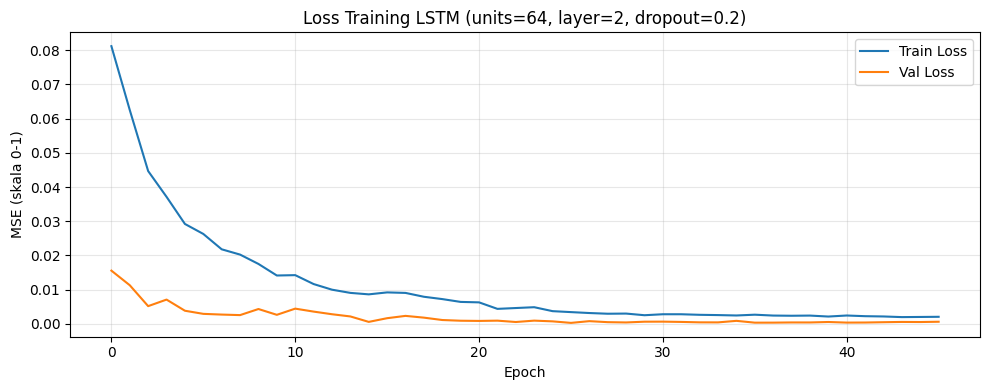

In [ ]:
# --- 14.2 Grafik loss training vs validasi -----------------------------------
plt.figure(figsize=(10, 4))
plt.plot(history_final.history['loss'], label='Train Loss')
plt.plot(history_final.history['val_loss'], label='Val Loss')
plt.title(f'Loss Training LSTM (units={FINAL_UNITS}, layer={FINAL_NLAYER}, dropout={FINAL_DROPOUT})')
plt.xlabel('Epoch'); plt.ylabel('MSE (skala 0-1)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/loss_training.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# --- 14.3 Prediksi & inverse transform (kembalikan ke skala kg, per komoditas) -
def prediksi_dan_evaluasi(model, X, y_scaled, K, nama_split):
    pred_scaled = model.predict(format_input(X, K, PAKAI_EMBEDDING), verbose=0)
    actual = inverse_target_per_komoditas(y_scaled, K)
    pred   = inverse_target_per_komoditas(pred_scaled, K)
    med_mape, _ = median_mape_per_komoditas(actual, pred, K)
    return {
        'split': nama_split,
        'MAPE(%)': hitung_mape(actual, pred),
        'MedianMAPE(%)': med_mape,
        'RMSE(kg)': hitung_rmse(actual, pred),
        'R2': r2_score(actual, pred),
    }, actual, pred

hasil_train, y_train_actual, y_train_pred = prediksi_dan_evaluasi(model_final, X_train, y_train, K_train, 'Train')
hasil_val,   y_val_actual,   y_val_pred   = prediksi_dan_evaluasi(model_final, X_val,   y_val,   K_val,   'Validation')
hasil_test,  y_test_actual,  y_test_pred  = prediksi_dan_evaluasi(model_final, X_test,  y_test,  K_test,  'Test')

df_evaluasi = pd.DataFrame([hasil_train, hasil_val, hasil_test]).set_index('split')
print('=== HASIL EVALUASI MODEL LSTM TERBAIK ===')
print(f'Encoding yang dipakai: {ENCODING_TERBAIK}')
print(df_evaluasi.round(3))

print(f"\nTarget Bab III: MAPE < 10%, R2 > 0.85")
print(f"Hasil Test -> MAPE (total, semua baris): {hasil_test['MAPE(%)']:.2f}%")
print(f"Hasil Test -> Median MAPE (per komoditas): {hasil_test['MedianMAPE(%)']:.2f}%")
print(f"Hasil Test -> R2: {hasil_test['R2']:.3f}  |  RMSE: {hasil_test['RMSE(kg)']:,.1f} kg")

=== HASIL EVALUASI MODEL LSTM TERBAIK ===
Encoding yang dipakai: One-Hot Encoding
            MAPE(%)  MedianMAPE(%)   RMSE(kg)     R2
split                                               
Train        17.332         13.548   6637.100  0.991
Validation   21.758         20.482   3277.704  0.908
Test         91.509         21.529  43140.317  0.775

Target Bab III: MAPE < 10%, R2 > 0.85
Hasil Test -> MAPE (total, semua baris): 91.51%
Hasil Test -> Median MAPE (per komoditas): 21.53%
Hasil Test -> R2: 0.775  |  RMSE: 43,140.3 kg


In [ ]:
# --- 14.4 Evaluasi per komoditas ---------------------------------------------
id_to_nama = {v: k for k, v in komoditas_mapping.items()}
df_hasil_test = pd.DataFrame({
    'komoditas_id': K_test,
    'aktual': y_test_actual,
    'prediksi': y_test_pred,
})
df_hasil_test['Nama'] = df_hasil_test['komoditas_id'].map(id_to_nama)

def mape_per_grup(g, eps=1e-6):
    mask = g['aktual'] > eps
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((g.loc[mask,'aktual'] - g.loc[mask,'prediksi']) / g.loc[mask,'aktual'])) * 100

mape_per_komoditas = df_hasil_test.groupby('Nama').apply(mape_per_grup, include_groups=False)
df_eval_komoditas = pd.DataFrame({'MAPE(%)': mape_per_komoditas})

# Pisahkan komoditas yang MAPE-nya terdefinisi vs tidak (semua actual test ~0 -> tidak bisa dihitung MAPE)
terdefinisi = df_eval_komoditas.dropna(subset=['MAPE(%)']).sort_values('MAPE(%)')
tidak_terdefinisi = df_eval_komoditas[df_eval_komoditas['MAPE(%)'].isna()]

print('=== MAPE per komoditas (test set), diurutkan dari terbaik ===')
print(terdefinisi.round(2))

print('\n3 Komoditas dengan MAPE TERBAIK:')
print(terdefinisi.head(3))
print('\n3 Komoditas dengan MAPE TERBURUK (di antara yang terdefinisi):')
print(terdefinisi.tail(3))

if len(tidak_terdefinisi) > 0:
    print(f'\n{len(tidak_terdefinisi)} komoditas TIDAK bisa dihitung MAPE-nya karena seluruh nilai '
          f'aktual pada test set mendekati/​sama dengan 0 (pembagian dengan angka mendekati nol '
          f'membuat MAPE tidak bermakna untuk komoditas ini):')
    print(tidak_terdefinisi.round(2))

print('\n=== Ringkasan statistik MAPE lintas komoditas (test set) ===')
print('Rata-rata (mean) MAPE lintas komoditas :', round(terdefinisi['MAPE(%)'].mean(), 2), '%')
print('Median MAPE lintas komoditas           :', round(terdefinisi['MAPE(%)'].median(), 2), '%')
print('Jumlah komoditas dengan MAPE < 50%     :', (terdefinisi['MAPE(%)'] < 50).sum(), 'dari', len(terdefinisi))
print('Jumlah komoditas dengan MAPE < 20%     :', (terdefinisi['MAPE(%)'] < 20).sum(), 'dari', len(terdefinisi))

=== MAPE per komoditas (test set), diurutkan dari terbaik ===
                MAPE(%)
Nama                   
Tomat              8.87
Cabai Rawit        9.32
Labu Siam         10.24
Cabai Keriting    10.62
Paprika           12.64
Kembang Kol       13.08
Cabai Besar       14.02
Kangkung          14.54
Kubis             17.54
Mentimun          21.27
Terung            21.79
Bawang Daun       30.71
Kentang           65.15
Buncis            65.45
Petsai/Sawi       74.69
Kacang Panjang    99.87
Jamur Tiram      103.53
Bayam            354.27
Bawang Merah     576.95
Wortel           618.49

3 Komoditas dengan MAPE TERBAIK:
               MAPE(%)
Nama                  
Tomat         8.869401
Cabai Rawit   9.315510
Labu Siam    10.236072

3 Komoditas dengan MAPE TERBURUK (di antara yang terdefinisi):
                 MAPE(%)
Nama                    
Bayam         354.274984
Bawang Merah  576.954496
Wortel        618.491920

6 komoditas TIDAK bisa dihitung MAPE-nya karena seluruh nilai aktual pa

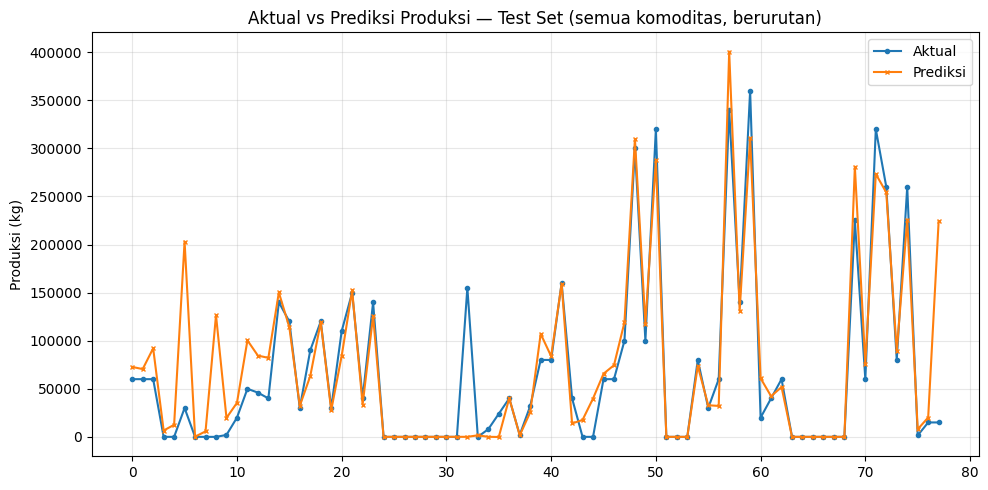

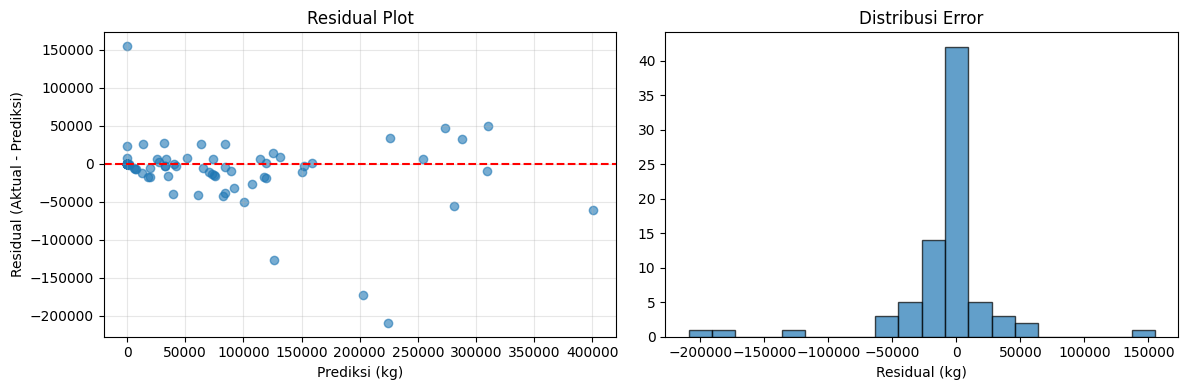

In [ ]:
# --- 14.5 Grafik aktual vs prediksi (keseluruhan test set) ------------------
plt.figure(figsize=(10, 5))
plt.plot(y_test_actual, label='Aktual', marker='o', ms=3)
plt.plot(y_test_pred, label='Prediksi', marker='x', ms=3)
plt.title('Aktual vs Prediksi Produksi — Test Set (semua komoditas, berurutan)')
plt.ylabel('Produksi (kg)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{ARTIFACT_DIR}/aktual_vs_prediksi.png', dpi=120, bbox_inches='tight')
plt.show()

# --- 14.6 Residual plot & distribusi error -----------------------------------
residual = y_test_actual - y_test_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test_pred, residual, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Prediksi (kg)'); axes[0].set_ylabel('Residual (Aktual - Prediksi)')
axes[0].set_title('Residual Plot'); axes[0].grid(alpha=0.3)

axes[1].hist(residual, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_title('Distribusi Error'); axes[1].set_xlabel('Residual (kg)')
plt.tight_layout(); plt.savefig(f'{ARTIFACT_DIR}/residual_plot.png', dpi=120, bbox_inches='tight')
plt.show()

## 16. Interpretasi SHAP

In [ ]:
# --- 16.1 Hitung SHAP value dengan GradientExplainer -------------------------
import shap

N_BACKGROUND = min(50, len(X_train))
N_SAMPLE_SHAP = min(50, len(X_test))
idx_background = np.random.choice(len(X_train), N_BACKGROUND, replace=False)

if PAKAI_EMBEDDING:
    # GradientExplainer tidak stabil untuk model 2-input (bug kompatibilitas shap/keras versi terbaru).
    # Fallback: KernelExplainer dengan ID komoditas DITETAPKAN pada nilai paling umum di sampel
    # (supaya SHAP fokus menjelaskan kontribusi FITUR SEQUENCE, bukan identitas komoditas mentah —
    # sesuai arahan: jangan memaksakan SHAP langsung pada ID komoditas kalau hasilnya tidak bermakna).
    # KernelExplainer lebih lambat -> jumlah sampel dibatasi lebih kecil.
    N_BACKGROUND = min(20, len(X_train))
    N_SAMPLE_SHAP = min(15, len(X_test))
    idx_background = np.random.choice(len(X_train), N_BACKGROUND, replace=False)
    id_representatif = np.array([np.bincount(K_test.astype(int)).argmax()], dtype='float32').reshape(1, 1)

    def f_prediksi_wrapper(seq_flat):
        seq = seq_flat.reshape(-1, TIMESTEP, N_FITUR_SEQUENCE)
        k_rep = np.tile(id_representatif, (seq.shape[0], 1))
        return model_final.predict([seq, k_rep], verbose=0).flatten()

    background = X_train[idx_background].reshape(N_BACKGROUND, -1)
    sample_shap = X_test[:N_SAMPLE_SHAP].reshape(N_SAMPLE_SHAP, -1)
    explainer = shap.KernelExplainer(f_prediksi_wrapper, background)
    shap_values_flat = explainer.shap_values(sample_shap, nsamples=100)
    shap_values = np.array(shap_values_flat).reshape(N_SAMPLE_SHAP, TIMESTEP, N_FITUR_SEQUENCE)
else:
    background = X_train[idx_background]
    sample_shap = X_test[:N_SAMPLE_SHAP]
    explainer = shap.GradientExplainer(model_final, background)
    shap_values = np.array(explainer.shap_values(sample_shap))
    if shap_values.ndim == 4:      # (sampel, timestep, fitur, 1) -> buang dimensi output tunggal
        shap_values = shap_values[..., 0]

print('Shape SHAP value (cabang sequence):', shap_values.shape, '-> (sampel, timestep, fitur)')
if PAKAI_EMBEDDING:
    print('Catatan: model pakai Embedding -> dipakai KernelExplainer dengan ID komoditas ditetapkan '
          'pada nilai paling umum, SHAP untuk ID komoditas mentah tidak diinterpretasi per-ID '
          '(lihat penjelasan di bawah).')

Shape SHAP value (cabang sequence): (50, 3, 35) -> (sampel, timestep, fitur)


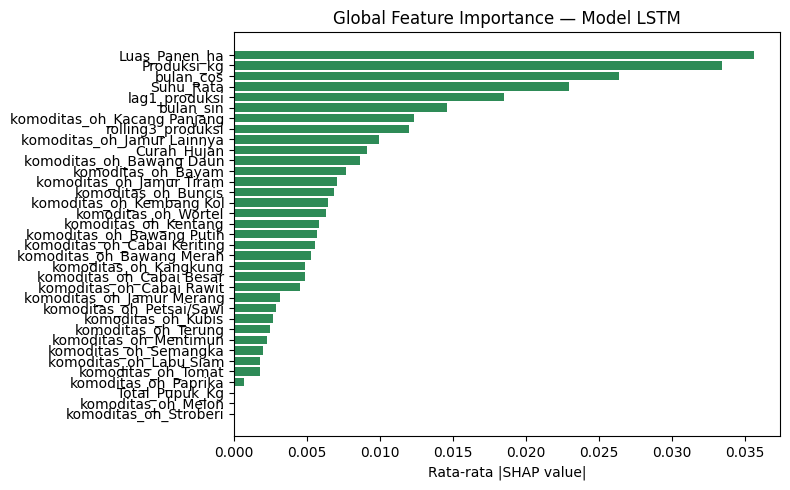

,Fitur,Importance
1,Luas_Panen_ha,0.035611
0,Produksi_kg,0.033404
6,bulan_cos,0.026375
2,Suhu_Rata,0.022916
7,lag1_produksi,0.018473
5,bulan_sin,0.014578
20,komoditas_oh_Kacang Panjang,0.012326
8,rolling3_produksi,0.012009
17,komoditas_oh_Jamur Lainnya,0.009946
3,Curah_Hujan,0.009133


In [ ]:
# --- 16.2 Global feature importance (dirata-ratakan lintas sampel & timestep) -
importance_per_fitur = np.abs(shap_values).mean(axis=(0, 1))
df_importance = pd.DataFrame({'Fitur': FEATURES_AKTIF, 'Importance': importance_per_fitur}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(df_importance['Fitur'], df_importance['Importance'], color='seagreen')
plt.xlabel('Rata-rata |SHAP value|')
plt.title('Global Feature Importance — Model LSTM')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.savefig(f'{ARTIFACT_DIR}/shap_global_importance.png', dpi=120, bbox_inches='tight')
plt.show()
df_importance

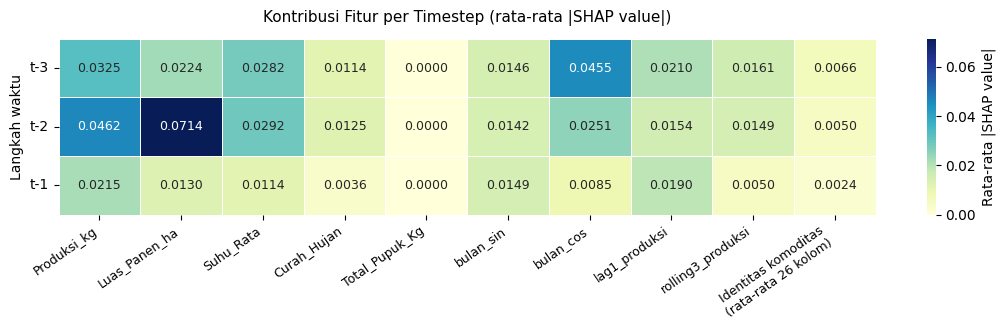


=== Kontribusi per timestep (fitur numerik) ===
     Produksi_kg  Luas_Panen_ha  Suhu_Rata  Curah_Hujan  Total_Pupuk_Kg  bulan_sin  bulan_cos  lag1_produksi  rolling3_produksi  Identitas komoditas\n(rata-rata 26 kolom)
t-3       0.0325         0.0224     0.0282       0.0114             0.0     0.0146     0.0455         0.0210             0.0161                                     0.0066
t-2       0.0462         0.0714     0.0292       0.0125             0.0     0.0142     0.0251         0.0154             0.0149                                     0.0050
t-1       0.0215         0.0130     0.0114       0.0036             0.0     0.0149     0.0085         0.0190             0.0050                                     0.0024

Total kontribusi per timestep:
t-3    0.3624
t-2    0.3596
t-1    0.1591


In [ ]:
# --- 16.3 Kontribusi fitur per timestep (versi siap cetak) -------------------
importance_per_timestep = np.abs(shap_values).mean(axis=0)   # (timestep, fitur)
df_ts = pd.DataFrame(importance_per_timestep, columns=FEATURES_AKTIF,
                     index=[f't-{TIMESTEP-i}' for i in range(TIMESTEP)])

# Pisahkan fitur numerik dari kolom identitas one-hot
kol_numerik = [c for c in FEATURES_AKTIF if not c.startswith('komoditas_oh_')]
kol_onehot  = [c for c in FEATURES_AKTIF if c.startswith('komoditas_oh_')]

df_ts_ringkas = df_ts[kol_numerik].copy()
if kol_onehot:
    df_ts_ringkas['Identitas komoditas\n(rata-rata 26 kolom)'] = df_ts[kol_onehot].mean(axis=1)

plt.figure(figsize=(11, 3.4))
ax = sns.heatmap(df_ts_ringkas, annot=True, fmt='.4f', cmap='YlGnBu',
                 linewidths=0.7, linecolor='white',
                 annot_kws={'size': 9},
                 cbar_kws={'label': 'Rata-rata |SHAP value|'})
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_ylabel('Langkah waktu')
plt.title('Kontribusi Fitur per Timestep (rata-rata |SHAP value|)', fontsize=11, pad=12)
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/shap_per_timestep.png', dpi=200, bbox_inches='tight')
plt.show()

# Cetak angkanya supaya bisa dipakai di naskah
print('\n=== Kontribusi per timestep (fitur numerik) ===')
print(df_ts_ringkas.round(4).to_string())
print('\nTotal kontribusi per timestep:')
print(df_ts.sum(axis=1).round(4).to_string())

## 17. Penyimpanan Model Terbaik & Fungsi Inferensi

In [ ]:
# --- 17.1 Simpan model, evaluasi, dan konfigurasi akhir ----------------------
model_final.save(f'{ARTIFACT_DIR}/lstm_model_terbaik.keras')

df_evaluasi.to_csv(f'{ARTIFACT_DIR}/tabel_evaluasi_final.csv')
if 'df_perbandingan' in globals():
    df_perbandingan.to_csv(f'{ARTIFACT_DIR}/tabel_perbandingan_model.csv')
else:
    print('Lampiran (perbandingan SimpleRNN/GRU/LSTM) belum dijalankan -> '
          'tabel_perbandingan_model.csv belum dibuat. Jalankan sel Lampiran di paling akhir notebook '
          'nanti saat sudah siap menulis Bab IV.2 Pembahasan.')
mape_per_komoditas.to_csv(f'{ARTIFACT_DIR}/mape_per_komoditas.csv')
df_eval_komoditas.to_csv(f'{ARTIFACT_DIR}/evaluasi_per_komoditas.csv')
df_hasil_test.to_csv(f'{ARTIFACT_DIR}/hasil_prediksi_test.csv', index=False)
df_importance.to_csv(f'{ARTIFACT_DIR}/shap_feature_importance.csv', index=False)

# Simpan juga one-hot encoder (dipakai kalau encoding terpilih One-Hot)
with open(f'{ARTIFACT_DIR}/onehot_encoder.pkl', 'wb') as f:
    pickle.dump(onehot_encoder, f)

konfigurasi_final = {
    'timestep': TIMESTEP,
    'features_dasar': FEATURES,
    'features_sequence': FEATURES_AKTIF,
    'target': TARGET,
    'target_idx': TARGET_IDX,
    'rnn_type': 'LSTM',
    'units': FINAL_UNITS,
    'n_layer': FINAL_NLAYER,
    'dropout': FINAL_DROPOUT,
    'learning_rate': FINAL_LR,
    'optimizer': FINAL_OPT,
    'batch_size': FINAL_BATCH,
    'n_komoditas': int(N_KOMODITAS),
    'encoding_terpilih': ENCODING_TERBAIK,
    'pakai_embedding': PAKAI_EMBEDDING,
    'sumber_hyperparameter': 'Bagian 13.4 (tuner lengkap)' if (GUNAKAN_HASIL_TUNER and not PAKAI_EMBEDDING) else 'Bagian 13.3 (neuron only)',
    'evaluasi_test': hasil_test,
}
with open(f'{ARTIFACT_DIR}/konfigurasi_model_final.json', 'w') as f:
    json.dump(konfigurasi_final, f, indent=2, default=str)

print('Model & seluruh artefak final tersimpan di:', ARTIFACT_DIR)
print('Encoding terpilih:', ENCODING_TERBAIK)
print(sorted(os.listdir(ARTIFACT_DIR)))

Lampiran (perbandingan SimpleRNN/GRU/LSTM) belum dijalankan -> tabel_perbandingan_model.csv belum dibuat. Jalankan sel Lampiran di paling akhir notebook nanti saat sudah siap menulis Bab IV.2 Pembahasan.
Model & seluruh artefak final tersimpan di: artefak_model
Encoding terpilih: One-Hot Encoding
['K_test.npy', 'K_train.npy', 'K_val.npy', 'X_test.npy', 'X_train.npy', 'X_val.npy', 'aktual_vs_prediksi.png', 'dataset_final_raw.csv', 'dataset_final_scaled.csv', 'evaluasi_per_komoditas.csv', 'feature_list.json', 'hasil_prediksi_test.csv', 'komoditas_mapping.json', 'konfigurasi_model_final.json', 'label_encoder.pkl', 'loss_training.png', 'lstm_model_terbaik.keras', 'mape_per_komoditas.csv', 'model_terbaik_sementara.keras', 'onehot_encoder.pkl', 'perbandingan_encoding.csv', 'residual_plot.png', 'scaler_per_komoditas.pkl', 'shap_feature_importance.csv', 'shap_global_importance.png', 'shap_per_timestep.png', 'tabel_evaluasi_final.csv', 'y_test.npy', 'y_train.npy', 'y_val.npy']


In [ ]:
# --- 17.2 Fungsi inferensi siap pakai untuk Streamlit ------------------------
def prediksi_produksi(data_3_bulan_terakhir: pd.DataFrame, nama_komoditas: str,
                       model=model_final, scaler_dict=scaler_per_komoditas, label_encoder=label_encoder,
                       onehot_encoder=onehot_encoder, fitur_dasar=FEATURES, target_idx=TARGET_IDX,
                       timestep=TIMESTEP, encoding=ENCODING_TERBAIK, pakai_embedding=PAKAI_EMBEDDING):
    """
    Prediksi produksi bulan berikutnya untuk 1 komoditas.
    Otomatis menyesuaikan cara encoding komoditas (Label/One-Hot/Embedding) dan memakai
    scaler PER KOMODITAS yang sesuai (Bagian 9) -> pemanggil CUKUP kasih data fitur mentah,
    tidak perlu tahu detail encoding/scaling-nya.

    Parameter
    ---------
    data_3_bulan_terakhir : DataFrame dengan `timestep` baris terurut kronologis,
        berisi kolom fitur dasar (Produksi_kg, Luas_Panen_ha, Suhu_Rata, Curah_Hujan,
        Total_Pupuk_Kg, bulan_sin, bulan_cos, lag1_produksi, rolling3_produksi) dalam skala ASLI.
    nama_komoditas : nama komoditas persis seperti di data training (setelah penyeragaman nama).

    Return
    ------
    float : prediksi produksi (kg) untuk bulan berikutnya.
    """
    if len(data_3_bulan_terakhir) != timestep:
        raise ValueError(f'Input harus berisi persis {timestep} baris (timestep), '
                          f'diterima {len(data_3_bulan_terakhir)} baris.')
    if nama_komoditas not in label_encoder.classes_:
        raise ValueError(f'Komoditas "{nama_komoditas}" tidak dikenali model. '
                          f'Komoditas yang dikenali: {list(label_encoder.classes_)}')

    kom_id = int(label_encoder.transform([nama_komoditas])[0])
    sc = scaler_dict[nama_komoditas]  # scaler KHUSUS komoditas ini (Bagian 9)

    # Scale fitur dasar pakai scaler milik komoditas ini sendiri
    fitur_scaled = sc.transform(data_3_bulan_terakhir[fitur_dasar])
    df_input_scaled = pd.DataFrame(fitur_scaled, columns=fitur_dasar)

    # Tambahkan kolom encoding komoditas sesuai metode yang terpilih (otomatis, tidak perlu manual)
    if encoding == 'Label Encoding':
        df_input_scaled['komoditas_id'] = kom_id / max(N_KOMODITAS - 1, 1)
        kolom_urut = fitur_dasar + ['komoditas_id']
    elif encoding == 'One-Hot Encoding':
        oh_value = onehot_encoder.transform([[nama_komoditas]])[0]
        oh_cols = [f'komoditas_oh_{c}' for c in onehot_encoder.categories_[0]]
        for col, val in zip(oh_cols, oh_value):
            df_input_scaled[col] = val
        kolom_urut = fitur_dasar + oh_cols
    else:
        kolom_urut = fitur_dasar  # Embedding: tidak perlu kolom tambahan di sequence

    X_input = df_input_scaled[kolom_urut].values.reshape(1, timestep, len(kolom_urut))

    if pakai_embedding:
        K_input = np.array([[kom_id]], dtype='float32')
        pred_scaled = model.predict([X_input, K_input], verbose=0)
    else:
        pred_scaled = model.predict(X_input, verbose=0)

    dummy = np.zeros((1, len(fitur_dasar)))
    dummy[0, target_idx] = np.array(pred_scaled).flatten()[0]
    pred_kg = sc.inverse_transform(dummy)[0, target_idx]
    return float(pred_kg)

# Contoh pemakaian (pakai 3 baris terakhir data test 1 komoditas sebagai contoh)
contoh_nama = 'Kentang'
contoh_data = df[(df['Nama'] == contoh_nama)].sort_values('Periode').tail(TIMESTEP)
try:
    hasil_contoh = prediksi_produksi(contoh_data, contoh_nama)
    print(f'Encoding yang dipakai: {ENCODING_TERBAIK}')
    print(f'Contoh prediksi produksi {contoh_nama} bulan berikutnya: {hasil_contoh:,.1f} kg')
except Exception as e:
    print('Contoh gagal (cek data):', e)

Encoding yang dipakai: One-Hot Encoding
Contoh prediksi produksi Kentang bulan berikutnya: 83,777.9 kg


# Perbandingan SimpleRNN vs GRU vs LSTM

In [ ]:
# --- L.1 Perbandingan SimpleRNN vs GRU vs LSTM (3 pengulangan seed) ---------
import time
from tensorflow.keras.layers import GRU, SimpleRNN

RNN_PEMBANDING = {'SimpleRNN': SimpleRNN, 'GRU': GRU, 'LSTM': LSTM}
N_REPEAT_RNN = 3

hasil_run = []
for rnn_type in ['SimpleRNN', 'GRU', 'LSTM']:
    for r in range(N_REPEAT_RNN):
        seed_run = SEED + r
        tf.random.set_seed(seed_run); np.random.seed(seed_run)
        model = bangun_model(units=FINAL_UNITS, dropout=FINAL_DROPOUT, n_layer=FINAL_NLAYER,
                             n_fitur=N_FITUR_SEQUENCE, rnn_layer=RNN_PEMBANDING[rnn_type],
                             learning_rate=FINAL_LR, optimizer_name=FINAL_OPT)
        es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        t0 = time.time()
        hist = model.fit(format_input(X_train_final, K_train_final, PAKAI_EMBEDDING), y_train_final,
                         validation_data=(format_input(X_val, K_val, PAKAI_EMBEDDING), y_val),
                         epochs=200, batch_size=FINAL_BATCH, callbacks=[es], verbose=0)
        waktu = time.time() - t0

        h_vl, *_ = prediksi_dan_evaluasi(model, X_val,  y_val,  K_val,  'val')
        h_ts, *_ = prediksi_dan_evaluasi(model, X_test, y_test, K_test, 'test')

        hasil_run.append({
            'Model': rnn_type, 'seed': seed_run,
            'Val_MAPE': h_vl['MAPE(%)'], 'Test_MAPE': h_ts['MAPE(%)'],
            'Test_MedianMAPE': h_ts['MedianMAPE(%)'],
            'Test_RMSE': h_ts['RMSE(kg)'], 'Test_R2': h_ts['R2'],
            'Waktu(s)': round(waktu, 1), 'Epoch': len(hist.history['loss']),
            'Parameter': model.count_params(),
        })
        print(f'{rnn_type:10s} seed={seed_run} | Test MAPE={h_ts["MAPE(%)"]:7.2f}% | '
              f'MedMAPE={h_ts["MedianMAPE(%)"]:6.2f}% | R2={h_ts["R2"]:6.3f} | {waktu:.0f}s')

df_run = pd.DataFrame(hasil_run)
df_perbandingan = df_run.groupby('Model').agg(
    Test_MAPE_mean=('Test_MAPE', 'mean'), Test_MAPE_std=('Test_MAPE', 'std'),
    Test_MedianMAPE_mean=('Test_MedianMAPE', 'mean'),
    Test_RMSE_mean=('Test_RMSE', 'mean'), Test_R2_mean=('Test_R2', 'mean'),
    Waktu_mean=('Waktu(s)', 'mean'), Parameter=('Parameter', 'first')
).round(3)

print('\n=== TABEL PERBANDINGAN ARSITEKTUR (rata-rata 3 seed) ===')
print(df_perbandingan.to_string())
print('\n=== Rincian per seed (untuk lampiran) ===')
print(df_run.round(3).to_string(index=False))

df_perbandingan.to_csv(f'{ARTIFACT_DIR}/tabel_perbandingan_model.csv')
df_run.to_csv(f'{ARTIFACT_DIR}/perbandingan_model_per_seed.csv', index=False)

SimpleRNN  seed=42 | Test MAPE=  92.35% | MedMAPE= 26.61% | R2= 0.780 | 59s
SimpleRNN  seed=43 | Test MAPE=  57.49% | MedMAPE= 20.98% | R2= 0.924 | 39s
SimpleRNN  seed=44 | Test MAPE=  84.29% | MedMAPE= 28.21% | R2= 0.864 | 38s
GRU        seed=42 | Test MAPE=  86.42% | MedMAPE= 29.64% | R2= 0.764 | 61s
GRU        seed=43 | Test MAPE= 101.02% | MedMAPE= 19.08% | R2= 0.773 | 44s
GRU        seed=44 | Test MAPE=  69.56% | MedMAPE= 24.56% | R2= 0.833 | 68s
LSTM       seed=42 | Test MAPE=  96.86% | MedMAPE= 25.34% | R2= 0.795 | 32s
LSTM       seed=43 | Test MAPE=  62.69% | MedMAPE= 25.06% | R2= 0.861 | 45s
LSTM       seed=44 | Test MAPE=  81.96% | MedMAPE= 31.52% | R2= 0.823 | 40s

=== TABEL PERBANDINGAN ARSITEKTUR (rata-rata 3 seed) ===
           Test_MAPE_mean  Test_MAPE_std  Test_MedianMAPE_mean  Test_RMSE_mean  Test_R2_mean  Waktu_mean  Parameter
Model                                                                                                              
GRU                85.665 